In [2]:
from pathlib import Path
import shutil

# --------------------------------------------------
# 1. PROJECT FOLDER
# --------------------------------------------------

PROJECT_DIR = Path.cwd().parent

# --------------------------------------------------
# 2. CREATE REQUIRED FOLDERS
# --------------------------------------------------

DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"
NOTEBOOK_DIR = PROJECT_DIR / "notebook"
RESULTS_DIR = PROJECT_DIR / "results"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# 3. DISPLAY STRUCTURE
# --------------------------------------------------

print("Project structure created successfully!\n")

print("PROJECT :", PROJECT_DIR)
print("DATA    :", DATA_DIR)
print("FIGURES :", FIGURES_DIR)
print("NOTEBOOK:", NOTEBOOK_DIR)
print("RESULTS :", RESULTS_DIR)

Project structure created successfully!

PROJECT : C:\Users\drish\OneDrive\assignment 2
DATA    : C:\Users\drish\OneDrive\assignment 2\data
FIGURES : C:\Users\drish\OneDrive\assignment 2\figures
NOTEBOOK: C:\Users\drish\OneDrive\assignment 2\notebook
RESULTS : C:\Users\drish\OneDrive\assignment 2\results


In [3]:
import pandas as pd

# Dataset location
DATA_FILE = DATA_DIR / "HospitalSynthetic1_cleaned.csv"

# Load dataset
df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (5000, 18)


,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,784,25,1,2,1,4,2,1,3,4,91534,8.0,1,2,2,41,5356,20
1,3250,10,2,5,2,4,2,3,5,2,11382,15.0,0,2,2,21,4735,51
2,7971,26,1,2,1,5,1,2,3,4,13449,8.0,1,2,4,71,4651,41
3,1415,23,0,6,0,4,2,1,5,3,125922,8.0,0,1,4,21,5292,20
4,5291,9,6,9,1,3,2,2,1,3,96482,8.0,1,2,2,21,4769,31


In [4]:
print("PROJECT FOLDER:", PROJECT_DIR)
print()

print("DATA FOLDER:")
for file in DATA_DIR.iterdir():
    print("  ", file.name)

print("\nFIGURES FOLDER:")
for file in FIGURES_DIR.iterdir():
    print("  ", file.name)

print("\nRESULTS FOLDER:")
for file in RESULTS_DIR.iterdir():
    print("  ", file.name)

PROJECT FOLDER: C:\Users\drish\OneDrive\assignment 2

DATA FOLDER:
   .ipynb_checkpoints
   HospitalSynthetic1_cleaned.csv

FIGURES FOLDER:
   correlation_heatmap.png
   execution_time_comparison.png
   knn_actual_vs_predicted.png
   knn_k_vs_rmse.png
   knn_residual_plot.png
   mae_comparison.png
   mlr_actual_vs_predicted.png
   mlr_residual_plot.png
   model_performance_comparison.png
   r2_comparison.png
   rmse_comparison.png
   target_distribution.png

RESULTS FOLDER:
   descriptive_statistics.csv
   final_model_summary.csv
   knn_tuning_results.csv
   model_metrics.csv
   predictions_knnr.csv
   predictions_mlr.csv
   resource_utilization.csv


In [5]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time
import os
import psutil

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
# ============================================================
# DATASET INSPECTION
# ============================================================

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (5000, 18)

Column names:
['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital', 'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade', 'patientid', 'City_Code_Patient', 'Type_of_Admission', 'Severity_of_Illness', 'Visitors_with_Patient', 'Age', 'Admission_Deposit', 'Stay']

Data types:
case_id                                int64
Hospital_code                          int64
Hospital_type_code                     int64
City_Code_Hospital                     int64
Hospital_region_code                   int64
Available_Extra_Rooms_in_Hospital      int64
Department                             int64
Ward_Type                              int64
Ward_Facility_Code                     int64
Bed_Grade                              int64
patientid                              int64
City_Code_Patient                    float64
Type_of_Admission                      int64
Severity_of_Illness       

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,784,25,1,2,1,4,2,1,3,4,91534,8.0,1,2,2,41,5356,20
1,3250,10,2,5,2,4,2,3,5,2,11382,15.0,0,2,2,21,4735,51
2,7971,26,1,2,1,5,1,2,3,4,13449,8.0,1,2,4,71,4651,41
3,1415,23,0,6,0,4,2,1,5,3,125922,8.0,0,1,4,21,5292,20
4,5291,9,6,9,1,3,2,2,1,3,96482,8.0,1,2,2,21,4769,31


In [7]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
case_id,5000.0,4391.6906,2797.020744,1.0,1819.75,4609.5,6552.50,9999.0
Hospital_code,5000.0,18.1306,8.886244,1.0,10.00,20.0,26.00,32.0
Hospital_type_code,5000.0,1.3914,1.575025,0.0,0.00,1.0,2.00,6.0
City_Code_Hospital,5000.0,4.7694,3.130588,1.0,2.00,5.0,7.00,13.0
Hospital_region_code,5000.0,0.7858,0.737582,0.0,0.00,1.0,1.00,2.0
Available_Extra_Rooms_in_Hospital,5000.0,3.3070,1.081751,1.0,3.00,3.0,4.00,8.0
Department,5000.0,1.9096,0.577836,0.0,2.00,2.0,2.00,4.0
Ward_Type,5000.0,1.9818,0.831148,0.0,1.00,2.0,3.00,4.0
Ward_Facility_Code,5000.0,3.2852,1.658436,0.0,2.00,4.0,5.00,5.0
Bed_Grade,5000.0,2.9146,0.873991,1.0,2.00,3.0,4.00,4.0


In [8]:
summary_stats = df.describe().T

summary_stats.to_csv(
    RESULTS_DIR / "descriptive_statistics.csv"
)

print("Descriptive statistics saved to:")
print(RESULTS_DIR / "descriptive_statistics.csv")

Descriptive statistics saved to:
C:\Users\drish\OneDrive\assignment 2\results\descriptive_statistics.csv


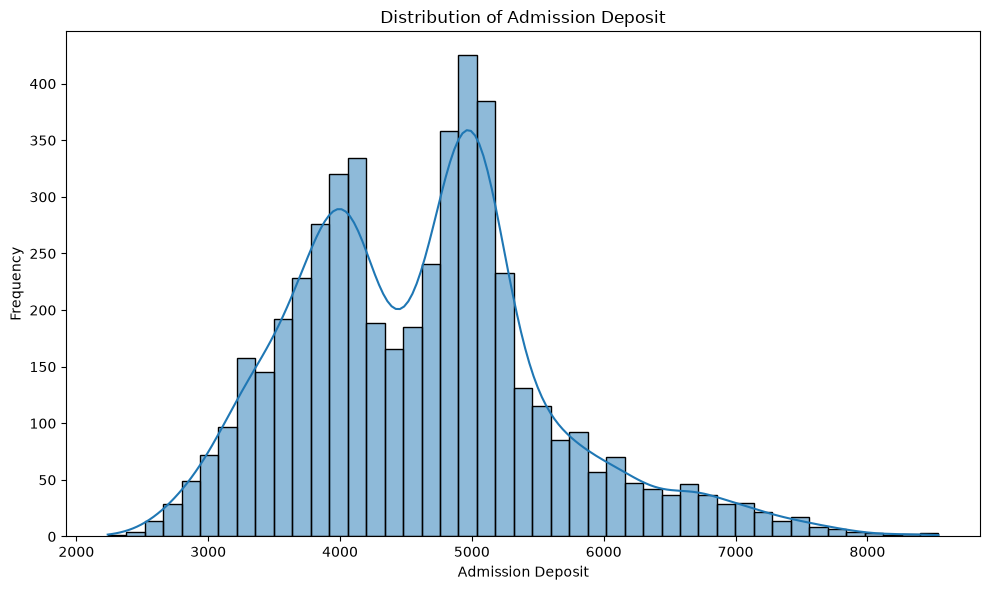

In [9]:
# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Admission_Deposit"],
    kde=True
)

plt.title("Distribution of Admission Deposit")
plt.xlabel("Admission Deposit")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

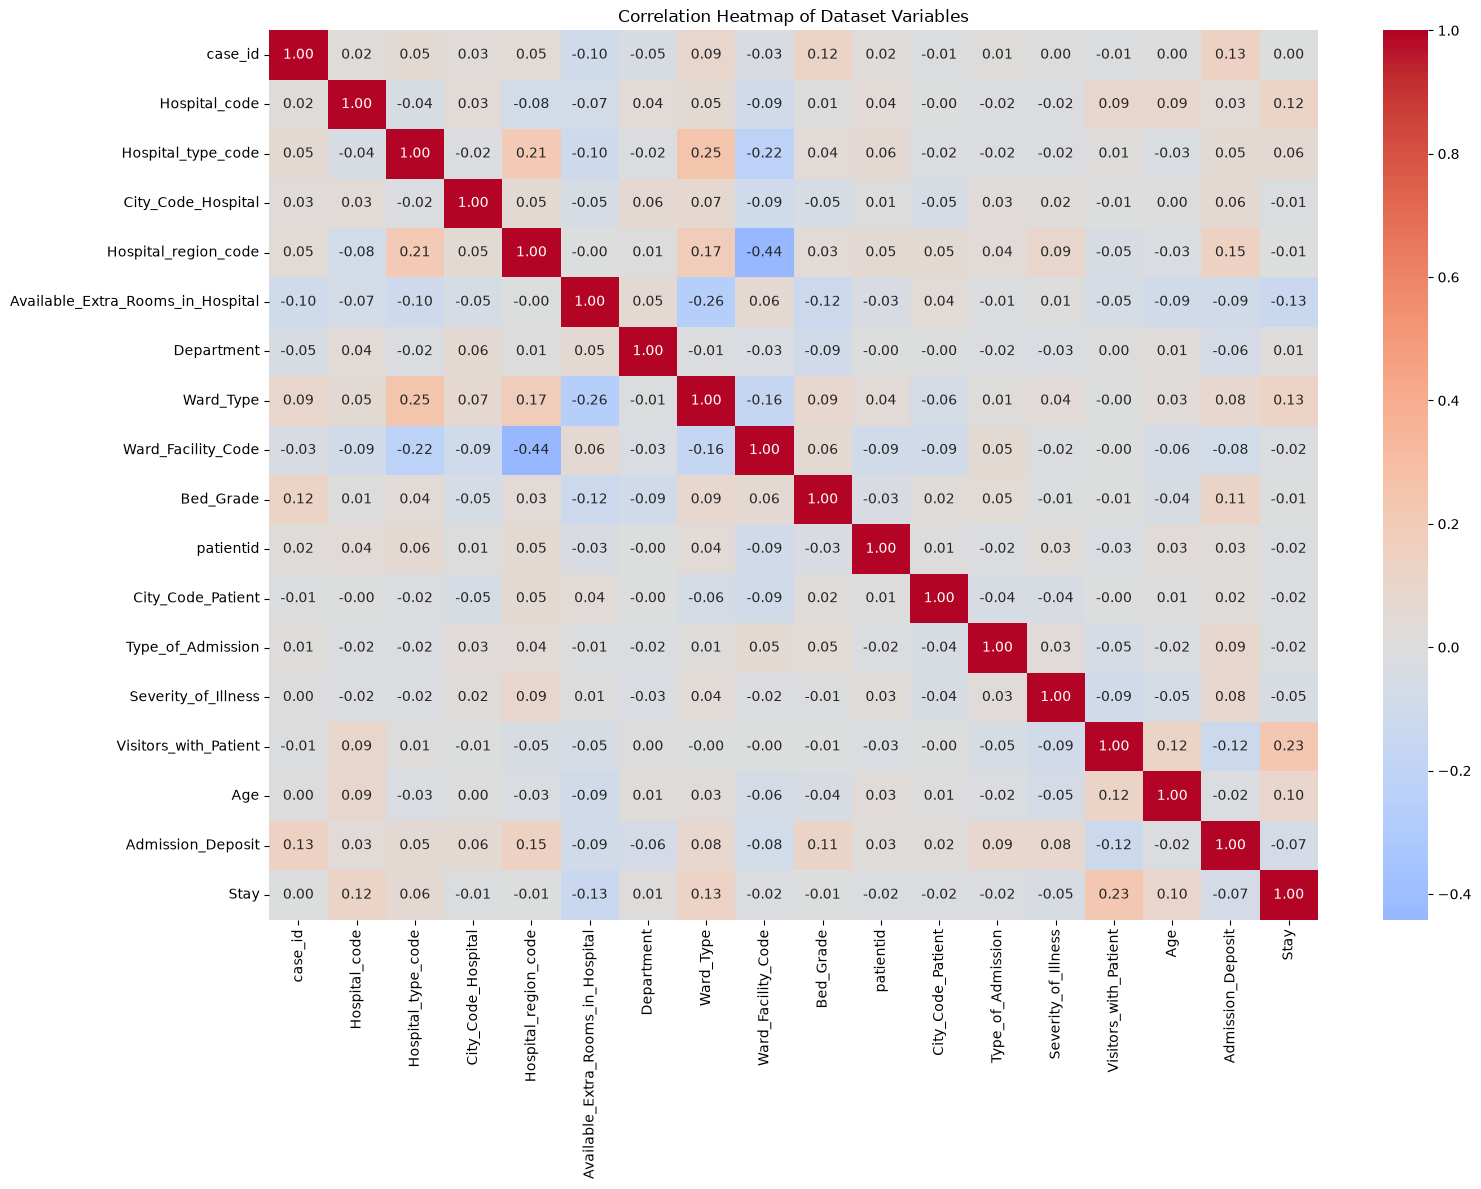

In [10]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(16, 12))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Dataset Variables")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [11]:
# ============================================================
# DEFINE FEATURES AND TARGET
# ============================================================

target = "Admission_Deposit"

X = df.drop(columns=[target])
y = df[target]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

print("\nFeatures used:")
print(X.columns.tolist())

Features (X): (5000, 17)
Target (y): (5000,)

Features used:
['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital', 'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade', 'patientid', 'City_Code_Patient', 'Type_of_Admission', 'Severity_of_Illness', 'Visitors_with_Patient', 'Age', 'Stay']


In [12]:
# ============================================================
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

categorical_columns = [
    "Hospital_code",
    "Hospital_type_code",
    "City_Code_Hospital",
    "Hospital_region_code",
    "Department",
    "Ward_Type",
    "Ward_Facility_Code",
    "Bed Grade",
    "City_Code_Patient",
    "Type of Admission",
    "Severity of Illness",
    "Age",
    "Stay"
]

categorical_columns = [
    col for col in categorical_columns
    if col in X.columns
]

numerical_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

print("Categorical features:")
print(categorical_columns)

print("\nNumerical features:")
print(numerical_columns)

Categorical features:
['Hospital_code', 'Hospital_type_code', 'City_Code_Hospital', 'Hospital_region_code', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'City_Code_Patient', 'Age', 'Stay']

Numerical features:
['case_id', 'Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'patientid', 'Type_of_Admission', 'Severity_of_Illness', 'Visitors_with_Patient']


In [13]:
# ============================================================
# REMOVE IDENTIFIER COLUMN
# ============================================================

if "case_id" in X.columns:
    X = X.drop(columns=["case_id"])

print("Final feature count:", X.shape[1])
print("\nFeatures:")
print(X.columns.tolist())

Final feature count: 16

Features:
['Hospital_code', 'Hospital_type_code', 'City_Code_Hospital', 'Hospital_region_code', 'Available_Extra_Rooms_in_Hospital', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed_Grade', 'patientid', 'City_Code_Patient', 'Type_of_Admission', 'Severity_of_Illness', 'Visitors_with_Patient', 'Age', 'Stay']


In [14]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 4000
Testing samples : 1000


In [15]:
# ============================================================
# FEATURE STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed.")

Feature standardization completed.


In [16]:
# ============================================================
# MULTIPLE LINEAR REGRESSION
# ============================================================

mlr = LinearRegression()

start_time = time.perf_counter()

mlr.fit(X_train_scaled, y_train)

mlr_training_time = time.perf_counter() - start_time

print("MLR model trained successfully.")
print("Training time:", mlr_training_time, "seconds")

MLR model trained successfully.
Training time: 0.0039040000119712204 seconds


In [17]:
# ============================================================
# MLR PREDICTIONS AND PERFORMANCE
# ============================================================

start_time = time.perf_counter()

y_pred_mlr = mlr.predict(X_test_scaled)

mlr_prediction_time = time.perf_counter() - start_time

mlr_r2 = r2_score(y_test, y_pred_mlr)
mlr_mae = mean_absolute_error(y_test, y_pred_mlr)
mlr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))

print("MLR PERFORMANCE")
print("---------------------------")
print("R²   :", mlr_r2)
print("MAE  :", mlr_mae)
print("RMSE :", mlr_rmse)
print("Prediction time:", mlr_prediction_time, "seconds")

MLR PERFORMANCE
---------------------------
R²   : 0.06773956309147877
MAE  : 738.0276319979965
RMSE : 949.3208399769654
Prediction time: 0.0005072999920230359 seconds


In [18]:
# ============================================================
# SAVE MLR PREDICTIONS
# ============================================================

mlr_predictions = pd.DataFrame({
    "Actual_Admission_Deposit": y_test.values,
    "Predicted_Admission_Deposit": y_pred_mlr
})

mlr_predictions.to_csv(
    RESULTS_DIR / "predictions_mlr.csv",
    index=False
)

print("MLR predictions saved:")
print(RESULTS_DIR / "predictions_mlr.csv")

MLR predictions saved:
C:\Users\drish\OneDrive\assignment 2\results\predictions_mlr.csv


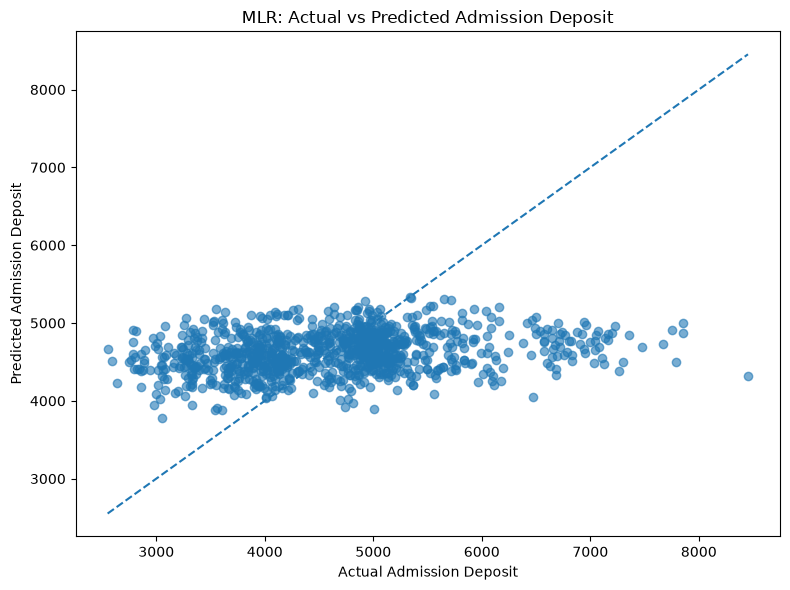

In [19]:
# ============================================================
# MLR: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_mlr,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_mlr.min())
max_value = max(y_test.max(), y_pred_mlr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("MLR: Actual vs Predicted Admission Deposit")
plt.xlabel("Actual Admission Deposit")
plt.ylabel("Predicted Admission Deposit")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "mlr_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

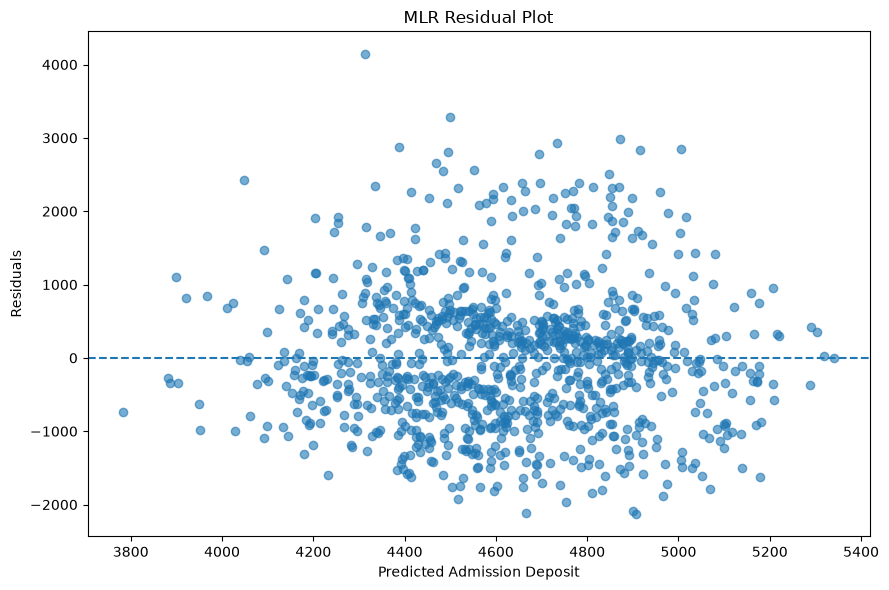

In [20]:
# ============================================================
# MLR RESIDUAL PLOT
# ============================================================

mlr_residuals = y_test - y_pred_mlr

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred_mlr,
    mlr_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("MLR Residual Plot")
plt.xlabel("Predicted Admission Deposit")
plt.ylabel("Residuals")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "mlr_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [21]:
# ============================================================
# KNN REGRESSION - HYPERPARAMETER TUNING
# ============================================================

k_values = range(1, 31)

knn_results = []

for k in k_values:

    knn = KNeighborsRegressor(n_neighbors=k)

    start_time = time.perf_counter()

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    execution_time = time.perf_counter() - start_time

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    knn_results.append({
        "K": k,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Execution_Time_Seconds": execution_time
    })

knn_results_df = pd.DataFrame(knn_results)

display(knn_results_df)

,K,R2,MAE,RMSE,Execution_Time_Seconds
0,1,-0.726357,1015.479000,1291.842743,1.495315
1,2,-0.355621,900.557000,1144.757606,0.006326
2,3,-0.196551,848.630667,1075.498919,0.007234
3,4,-0.141003,824.155500,1050.237974,0.007182
4,5,-0.087056,799.634800,1025.109663,0.008594
5,6,-0.048519,788.181833,1006.775197,0.009855
6,7,-0.030456,780.475571,998.065561,0.010444
7,8,-0.022513,774.527750,994.211717,0.010818
8,9,-0.009292,767.628556,987.763310,0.010181
9,10,0.002655,759.594500,981.899608,0.010210


In [22]:
# ============================================================
# SAVE KNN TUNING RESULTS
# ============================================================

knn_results_df.to_csv(
    RESULTS_DIR / "knn_tuning_results.csv",
    index=False
)

print("KNN tuning results saved to:")
print(RESULTS_DIR / "knn_tuning_results.csv")

KNN tuning results saved to:
C:\Users\drish\OneDrive\assignment 2\results\knn_tuning_results.csv


In [23]:
# ============================================================
# SELECT BEST K
# ============================================================

best_k_row = knn_results_df.loc[
    knn_results_df["RMSE"].idxmin()
]

best_k = int(best_k_row["K"])

print("Best K:", best_k)
print("Best K RMSE:", best_k_row["RMSE"])
print("Best K MAE:", best_k_row["MAE"])
print("Best K R²:", best_k_row["R2"])

Best K: 27
Best K RMSE: 953.5988168285393
Best K MAE: 733.6254814814814
Best K R²: 0.05931843822526828


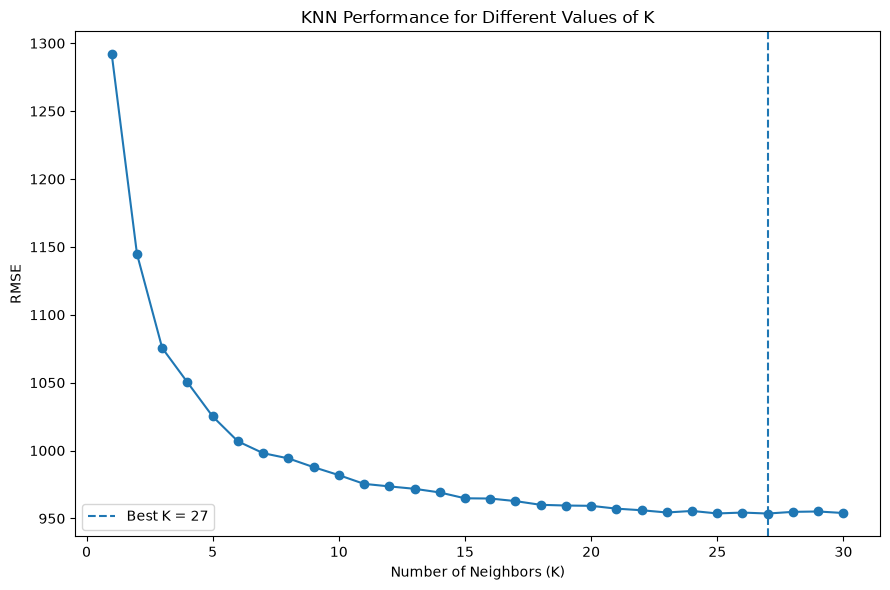

In [24]:
# ============================================================
# KNN HYPERPARAMETER PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    knn_results_df["K"],
    knn_results_df["RMSE"],
    marker="o"
)

plt.axvline(
    best_k,
    linestyle="--",
    label=f"Best K = {best_k}"
)

plt.title("KNN Performance for Different Values of K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "knn_k_vs_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [25]:
# ============================================================
# FINAL KNN REGRESSION MODEL
# ============================================================

knn_final = KNeighborsRegressor(
    n_neighbors=best_k
)

start_time = time.perf_counter()

knn_final.fit(
    X_train_scaled,
    y_train
)

knn_training_time = time.perf_counter() - start_time

print("Final KNN model trained successfully.")
print("Selected K:", best_k)
print("Training time:", knn_training_time, "seconds")

Final KNN model trained successfully.
Selected K: 27
Training time: 0.001788599998690188 seconds


In [26]:
# ============================================================
# KNN PREDICTIONS AND PERFORMANCE
# ============================================================

start_time = time.perf_counter()

y_pred_knn = knn_final.predict(X_test_scaled)

knn_prediction_time = time.perf_counter() - start_time

knn_r2 = r2_score(y_test, y_pred_knn)
knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("KNN REGRESSION PERFORMANCE")
print("---------------------------")
print("Best K:", best_k)
print("R²   :", knn_r2)
print("MAE  :", knn_mae)
print("RMSE :", knn_rmse)
print("Prediction time:", knn_prediction_time, "seconds")

KNN REGRESSION PERFORMANCE
---------------------------
Best K: 27
R²   : 0.05931843822526828
MAE  : 733.6254814814814
RMSE : 953.5988168285393
Prediction time: 0.015340400015702471 seconds


In [27]:
# ============================================================
# SAVE KNN PREDICTIONS
# ============================================================

knn_predictions = pd.DataFrame({
    "Actual_Admission_Deposit": y_test.values,
    "Predicted_Admission_Deposit": y_pred_knn
})

knn_predictions.to_csv(
    RESULTS_DIR / "predictions_knnr.csv",
    index=False
)

print("KNN predictions saved to:")
print(RESULTS_DIR / "predictions_knnr.csv")

KNN predictions saved to:
C:\Users\drish\OneDrive\assignment 2\results\predictions_knnr.csv


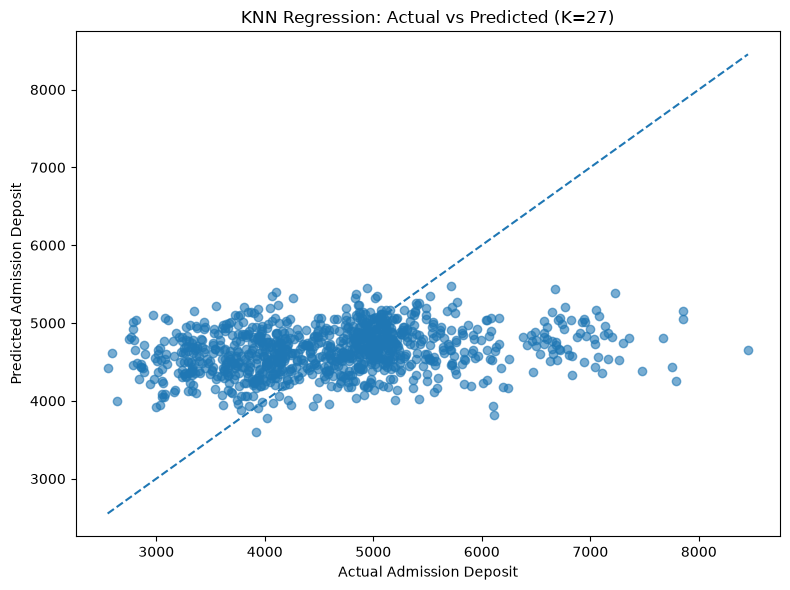

In [28]:
# ============================================================
# KNN: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_knn,
    alpha=0.6
)

min_value = min(y_test.min(), y_pred_knn.min())
max_value = max(y_test.max(), y_pred_knn.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(f"KNN Regression: Actual vs Predicted (K={best_k})")
plt.xlabel("Actual Admission Deposit")
plt.ylabel("Predicted Admission Deposit")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "knn_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

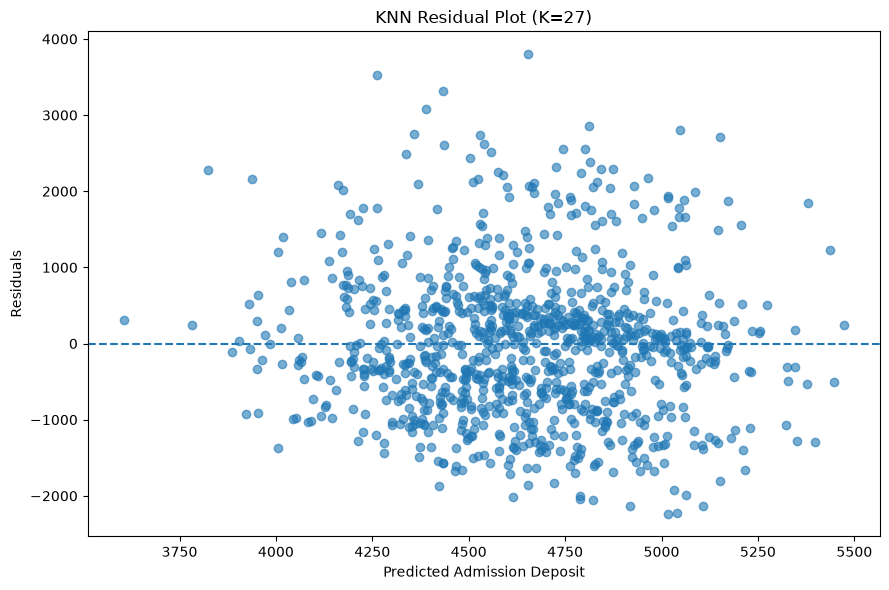

In [29]:
# ============================================================
# KNN RESIDUAL PLOT
# ============================================================

knn_residuals = y_test - y_pred_knn

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred_knn,
    knn_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(f"KNN Residual Plot (K={best_k})")
plt.xlabel("Predicted Admission Deposit")
plt.ylabel("Residuals")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "knn_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [30]:
# ============================================================
# MODEL PERFORMANCE COMPARISON
# ============================================================

model_metrics = pd.DataFrame({
    "Model": ["Multiple Linear Regression", "KNN Regression"],
    "R2": [mlr_r2, knn_r2],
    "MAE": [mlr_mae, knn_mae],
    "RMSE": [mlr_rmse, knn_rmse],
    "Training_Time_Seconds": [
        mlr_training_time,
        knn_training_time
    ],
    "Prediction_Time_Seconds": [
        mlr_prediction_time,
        knn_prediction_time
    ]
})

display(model_metrics)

,Model,R2,MAE,RMSE,Training_Time_Seconds,Prediction_Time_Seconds
0,Multiple Linear Regression,0.067740,738.027632,949.320840,0.003904,0.000507
1,KNN Regression,0.059318,733.625481,953.598817,0.001789,0.015340


In [31]:
# ============================================================
# SAVE MODEL METRICS
# ============================================================

model_metrics.to_csv(
    RESULTS_DIR / "model_metrics.csv",
    index=False
)

print("Model metrics saved to:")
print(RESULTS_DIR / "model_metrics.csv")

Model metrics saved to:
C:\Users\drish\OneDrive\assignment 2\results\model_metrics.csv


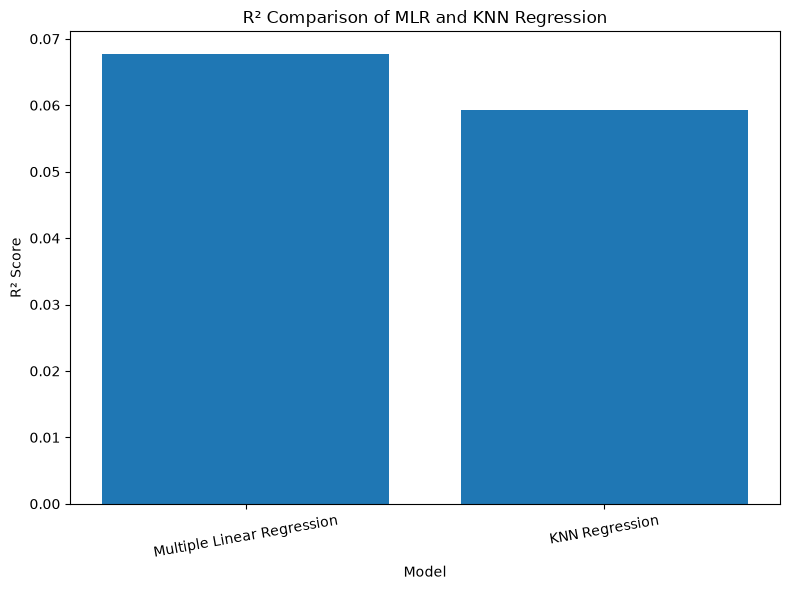

In [32]:
# ============================================================
# R² COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    model_metrics["Model"],
    model_metrics["R2"]
)

plt.title("R² Comparison of MLR and KNN Regression")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

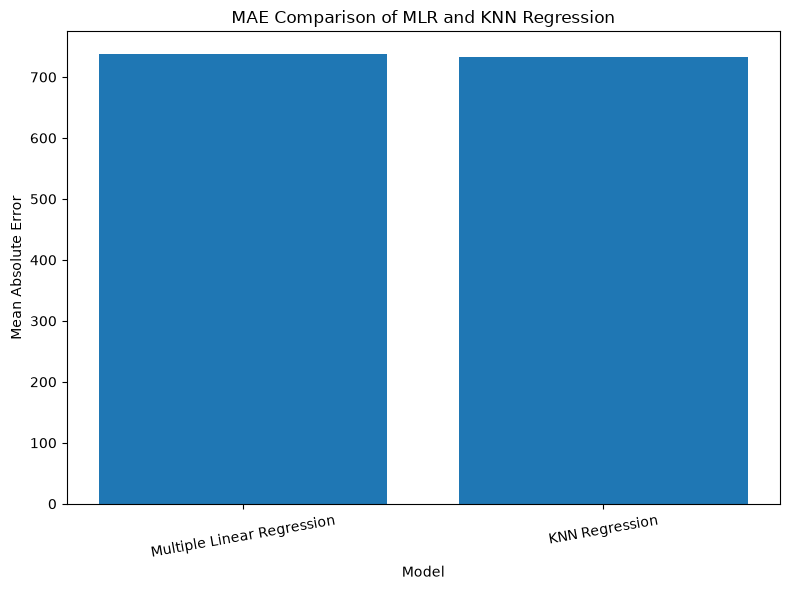

In [33]:
# ============================================================
# MAE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    model_metrics["Model"],
    model_metrics["MAE"]
)

plt.title("MAE Comparison of MLR and KNN Regression")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

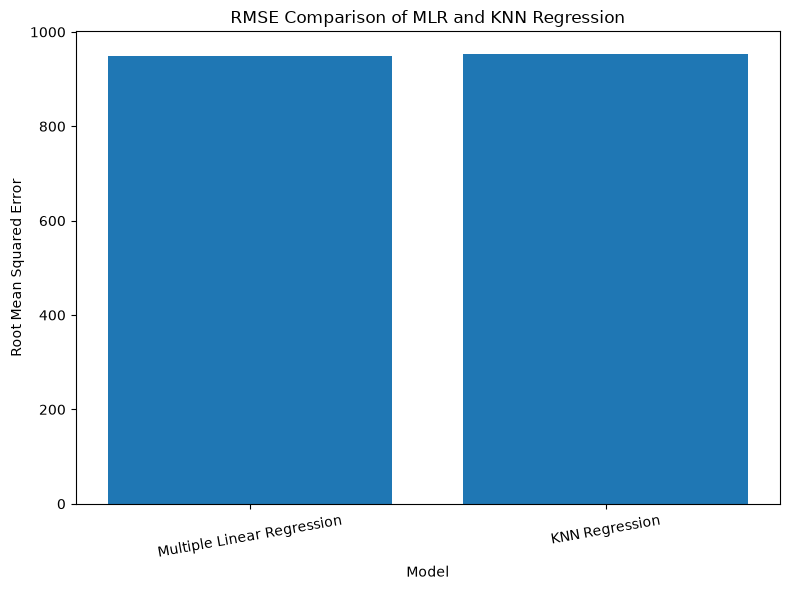

In [34]:
# ============================================================
# RMSE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

plt.bar(
    model_metrics["Model"],
    model_metrics["RMSE"]
)

plt.title("RMSE Comparison of MLR and KNN Regression")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

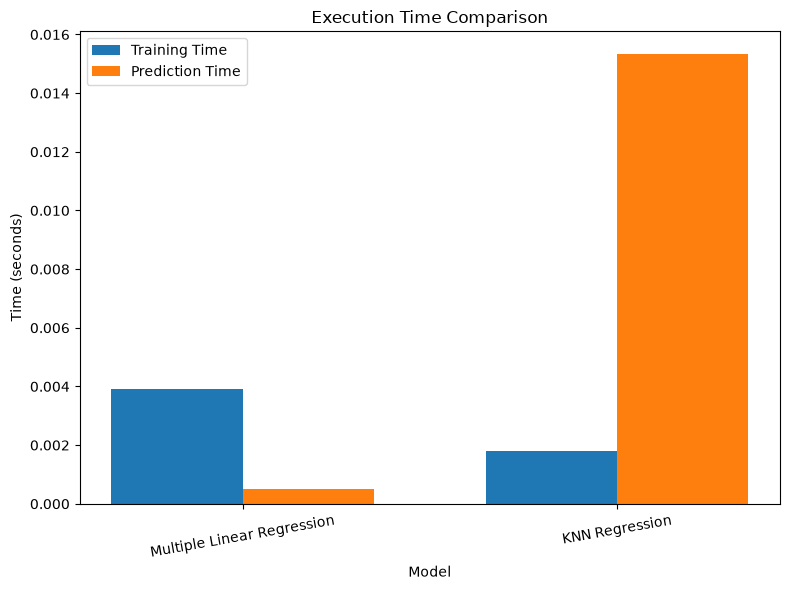

In [35]:
# ============================================================
# EXECUTION TIME COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

x = np.arange(len(model_metrics["Model"]))
width = 0.35

plt.bar(
    x - width/2,
    model_metrics["Training_Time_Seconds"],
    width,
    label="Training Time"
)

plt.bar(
    x + width/2,
    model_metrics["Prediction_Time_Seconds"],
    width,
    label="Prediction Time"
)

plt.xticks(
    x,
    model_metrics["Model"],
    rotation=10
)

plt.title("Execution Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "execution_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [36]:
# ============================================================
# MEMORY UTILIZATION
# ============================================================

process = psutil.Process(os.getpid())

# Current memory usage
memory_after_models_mb = process.memory_info().rss / (1024 ** 2)

resource_utilization = pd.DataFrame({
    "Measurement": [
        "Process Memory Usage After Model Execution"
    ],
    "Value_MB": [
        memory_after_models_mb
    ]
})

display(resource_utilization)

,Measurement,Value_MB
0,Process Memory Usage After Model Execution,285.011719


In [37]:
# ============================================================
# SAVE RESOURCE UTILIZATION
# ============================================================

resource_utilization.to_csv(
    RESULTS_DIR / "resource_utilization.csv",
    index=False
)

print("Resource utilization saved to:")
print(RESULTS_DIR / "resource_utilization.csv")

Resource utilization saved to:
C:\Users\drish\OneDrive\assignment 2\results\resource_utilization.csv


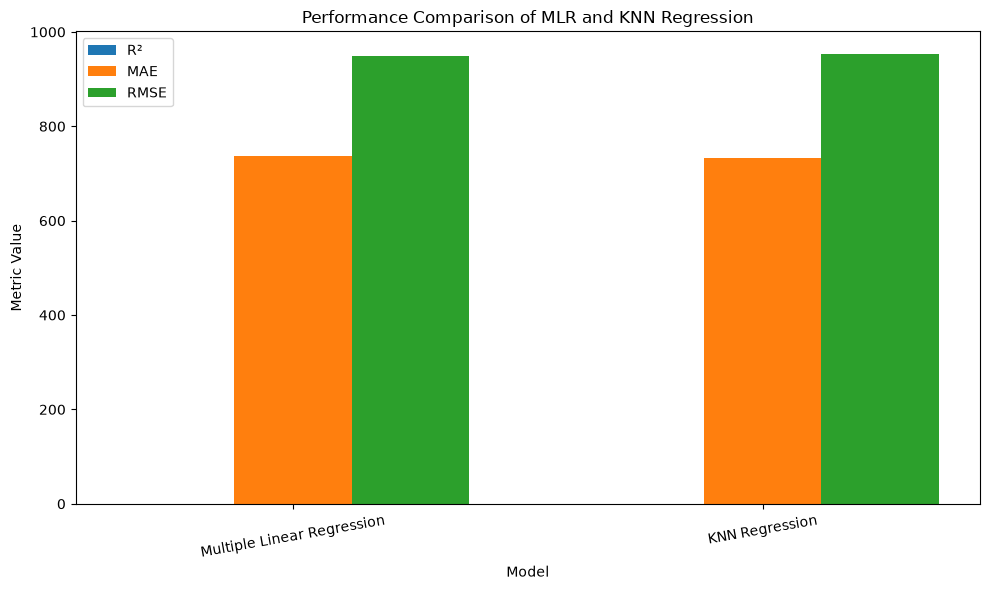

In [38]:
# ============================================================
# COMBINED MODEL PERFORMANCE
# ============================================================

x = np.arange(len(model_metrics["Model"]))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    model_metrics["R2"],
    width,
    label="R²"
)

plt.bar(
    x,
    model_metrics["MAE"],
    width,
    label="MAE"
)

plt.bar(
    x + width,
    model_metrics["RMSE"],
    width,
    label="RMSE"
)

plt.xticks(
    x,
    model_metrics["Model"],
    rotation=10
)

plt.title("Performance Comparison of MLR and KNN Regression")
plt.xlabel("Model")
plt.ylabel("Metric Value")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [39]:
# ============================================================
# FINAL RESULTS
# ============================================================

final_results = model_metrics.copy()

final_results["R2"] = final_results["R2"].round(4)
final_results["MAE"] = final_results["MAE"].round(2)
final_results["RMSE"] = final_results["RMSE"].round(2)
final_results["Training_Time_Seconds"] = (
    final_results["Training_Time_Seconds"].round(6)
)
final_results["Prediction_Time_Seconds"] = (
    final_results["Prediction_Time_Seconds"].round(6)
)

display(final_results)

,Model,R2,MAE,RMSE,Training_Time_Seconds,Prediction_Time_Seconds
0,Multiple Linear Regression,0.0677,738.03,949.32,0.003904,0.000507
1,KNN Regression,0.0593,733.63,953.60,0.001789,0.015340


In [40]:
# ============================================================
# VERIFY ALL OUTPUT FILES
# ============================================================

print("========== RESULTS FILES ==========")

for file in sorted(RESULTS_DIR.iterdir()):
    print(file.name)

print("\n========== FIGURE FILES ==========")

for file in sorted(FIGURES_DIR.iterdir()):
    print(file.name)

========== RESULTS FILES ==========
descriptive_statistics.csv
final_model_summary.csv
knn_tuning_results.csv
model_metrics.csv
predictions_knnr.csv
predictions_mlr.csv
resource_utilization.csv

========== FIGURE FILES ==========
correlation_heatmap.png
execution_time_comparison.png
knn_actual_vs_predicted.png
knn_k_vs_rmse.png
knn_residual_plot.png
mae_comparison.png
mlr_actual_vs_predicted.png
mlr_residual_plot.png
model_performance_comparison.png
r2_comparison.png
rmse_comparison.png
target_distribution.png


In [41]:
# ============================================================
# FINAL MODEL SUMMARY
# ============================================================

final_summary = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "KNN Regression"
    ],
    "R2": [
        mlr_r2,
        knn_r2
    ],
    "MAE": [
        mlr_mae,
        knn_mae
    ],
    "RMSE": [
        mlr_rmse,
        knn_rmse
    ],
    "Training_Time_Seconds": [
        mlr_training_time,
        knn_training_time
    ],
    "Prediction_Time_Seconds": [
        mlr_prediction_time,
        knn_prediction_time
    ]
})

# Round values for clean presentation
final_summary["R2"] = final_summary["R2"].round(4)
final_summary["MAE"] = final_summary["MAE"].round(2)
final_summary["RMSE"] = final_summary["RMSE"].round(2)
final_summary["Training_Time_Seconds"] = (
    final_summary["Training_Time_Seconds"].round(6)
)
final_summary["Prediction_Time_Seconds"] = (
    final_summary["Prediction_Time_Seconds"].round(6)
)

display(final_summary)

,Model,R2,MAE,RMSE,Training_Time_Seconds,Prediction_Time_Seconds
0,Multiple Linear Regression,0.0677,738.03,949.32,0.003904,0.000507
1,KNN Regression,0.0593,733.63,953.60,0.001789,0.015340


In [42]:
# ============================================================
# SAVE FINAL SUMMARY
# ============================================================

final_summary.to_csv(
    RESULTS_DIR / "final_model_summary.csv",
    index=False
)

print("Final model summary saved to:")
print(RESULTS_DIR / "final_model_summary.csv")

Final model summary saved to:
C:\Users\drish\OneDrive\assignment 2\results\final_model_summary.csv


In [43]:
# ============================================================
# AUTOMATIC RESULT INTERPRETATION
# ============================================================

print("========== FINAL MODEL COMPARISON ==========\n")

print(f"MLR R²   : {mlr_r2:.4f}")
print(f"MLR MAE  : {mlr_mae:.2f}")
print(f"MLR RMSE : {mlr_rmse:.2f}")

print()

print(f"KNN R²   : {knn_r2:.4f}")
print(f"KNN MAE  : {knn_mae:.2f}")
print(f"KNN RMSE : {knn_rmse:.2f}")

print("\n========== KNN TUNING ==========")
print(f"Best K   : {best_k}")
print(f"Best RMSE: {knn_rmse:.2f}")

print("\n========== EXECUTION TIME ==========")
print(f"MLR training time : {mlr_training_time:.6f} seconds")
print(f"MLR prediction time: {mlr_prediction_time:.6f} seconds")
print(f"KNN training time : {knn_training_time:.6f} seconds")
print(f"KNN prediction time: {knn_prediction_time:.6f} seconds")

print("\n========== RESOURCE UTILIZATION ==========")
print(f"Python process memory usage: {memory_after_models_mb:.2f} MB")

========== FINAL MODEL COMPARISON ==========

MLR R²   : 0.0677
MLR MAE  : 738.03
MLR RMSE : 949.32

KNN R²   : 0.0593
KNN MAE  : 733.63
KNN RMSE : 953.60

========== KNN TUNING ==========
Best K   : 27
Best RMSE: 953.60

========== EXECUTION TIME ==========
MLR training time : 0.003904 seconds
MLR prediction time: 0.000507 seconds
KNN training time : 0.001789 seconds
KNN prediction time: 0.015340 seconds

========== RESOURCE UTILIZATION ==========
Python process memory usage: 285.01 MB


In [44]:
# ============================================================
# FINAL PROJECT FILE CHECK
# ============================================================

print("=" * 60)
print("FINAL ASSIGNMENT 2 PROJECT STRUCTURE")
print("=" * 60)

print("\n📁 DATA")
for file in sorted(DATA_DIR.iterdir()):
    print("   └──", file.name)

print("\n📁 FIGURES")
for file in sorted(FIGURES_DIR.iterdir()):
    print("   └──", file.name)

print("\n📁 RESULTS")
for file in sorted(RESULTS_DIR.iterdir()):
    print("   └──", file.name)

print("\n" + "=" * 60)
print("ALL OUTPUTS GENERATED SUCCESSFULLY")
print("=" * 60)

FINAL ASSIGNMENT 2 PROJECT STRUCTURE

📁 DATA
   └── .ipynb_checkpoints
   └── HospitalSynthetic1_cleaned.csv

📁 FIGURES
   └── correlation_heatmap.png
   └── execution_time_comparison.png
   └── knn_actual_vs_predicted.png
   └── knn_k_vs_rmse.png
   └── knn_residual_plot.png
   └── mae_comparison.png
   └── mlr_actual_vs_predicted.png
   └── mlr_residual_plot.png
   └── model_performance_comparison.png
   └── r2_comparison.png
   └── rmse_comparison.png
   └── target_distribution.png

📁 RESULTS
   └── descriptive_statistics.csv
   └── final_model_summary.csv
   └── knn_tuning_results.csv
   └── model_metrics.csv
   └── predictions_knnr.csv
   └── predictions_mlr.csv
   └── resource_utilization.csv

ALL OUTPUTS GENERATED SUCCESSFULLY


Total figures: 12

correlation_heatmap.png


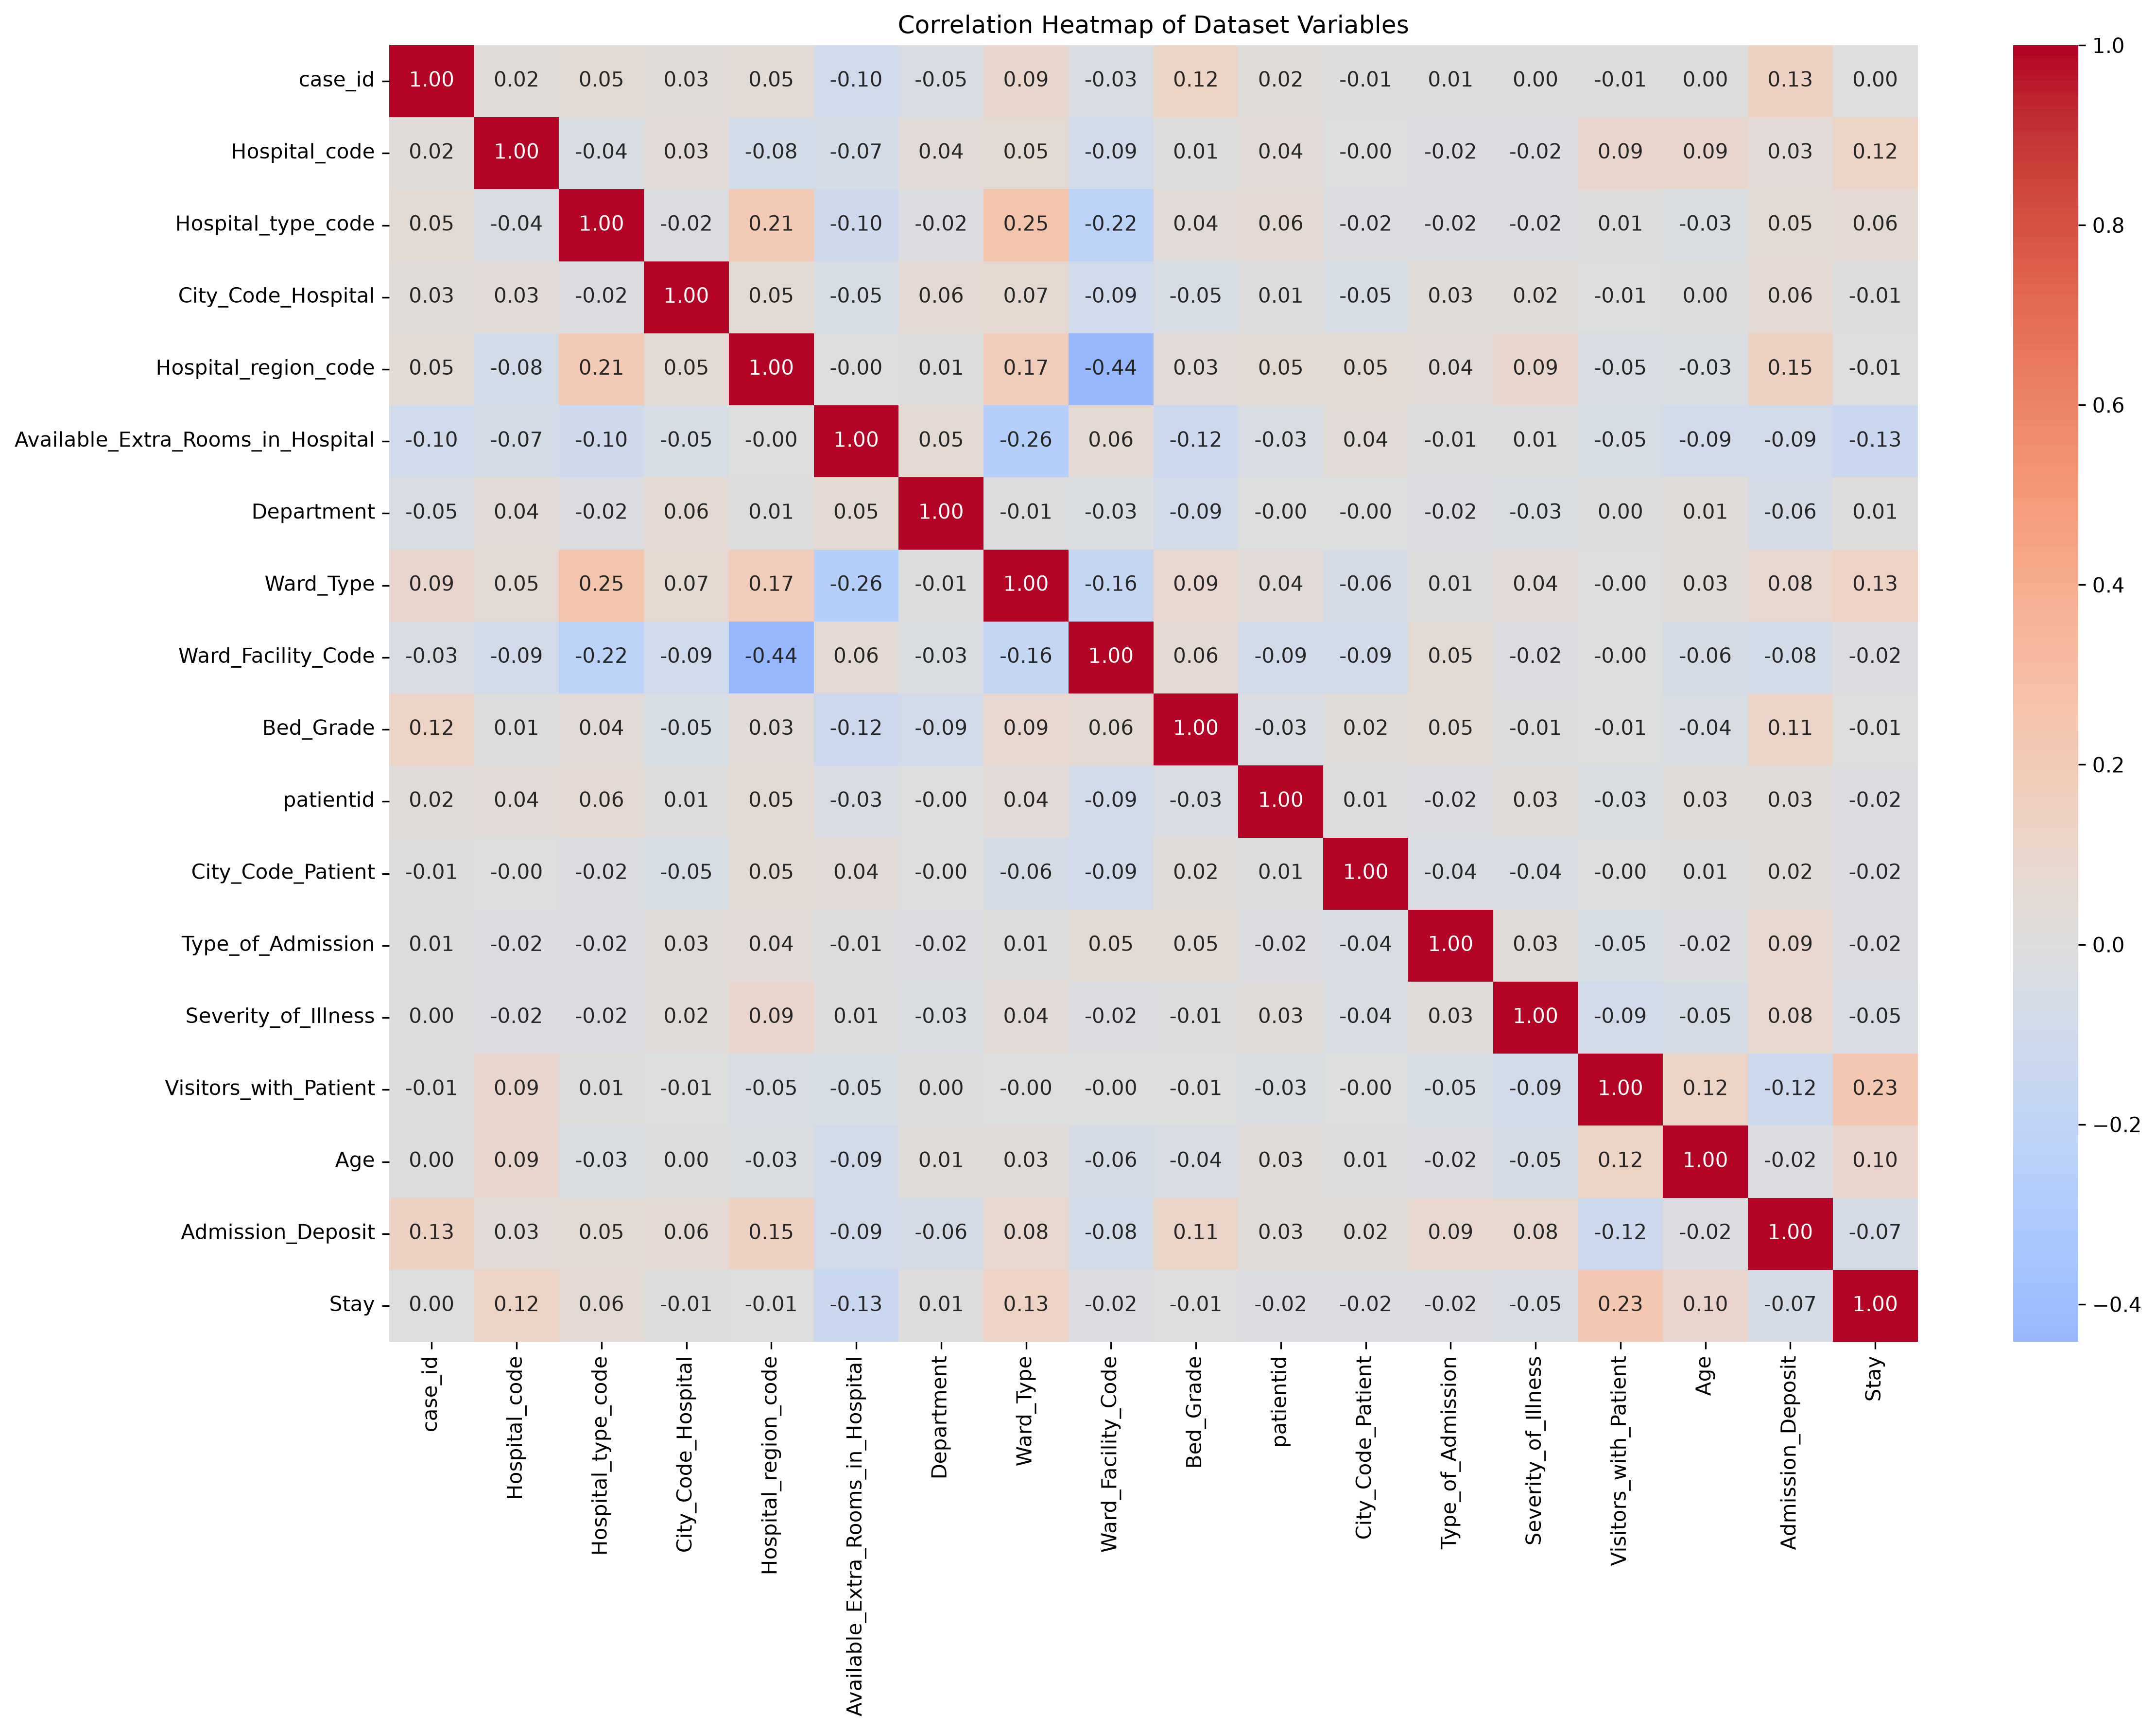

execution_time_comparison.png


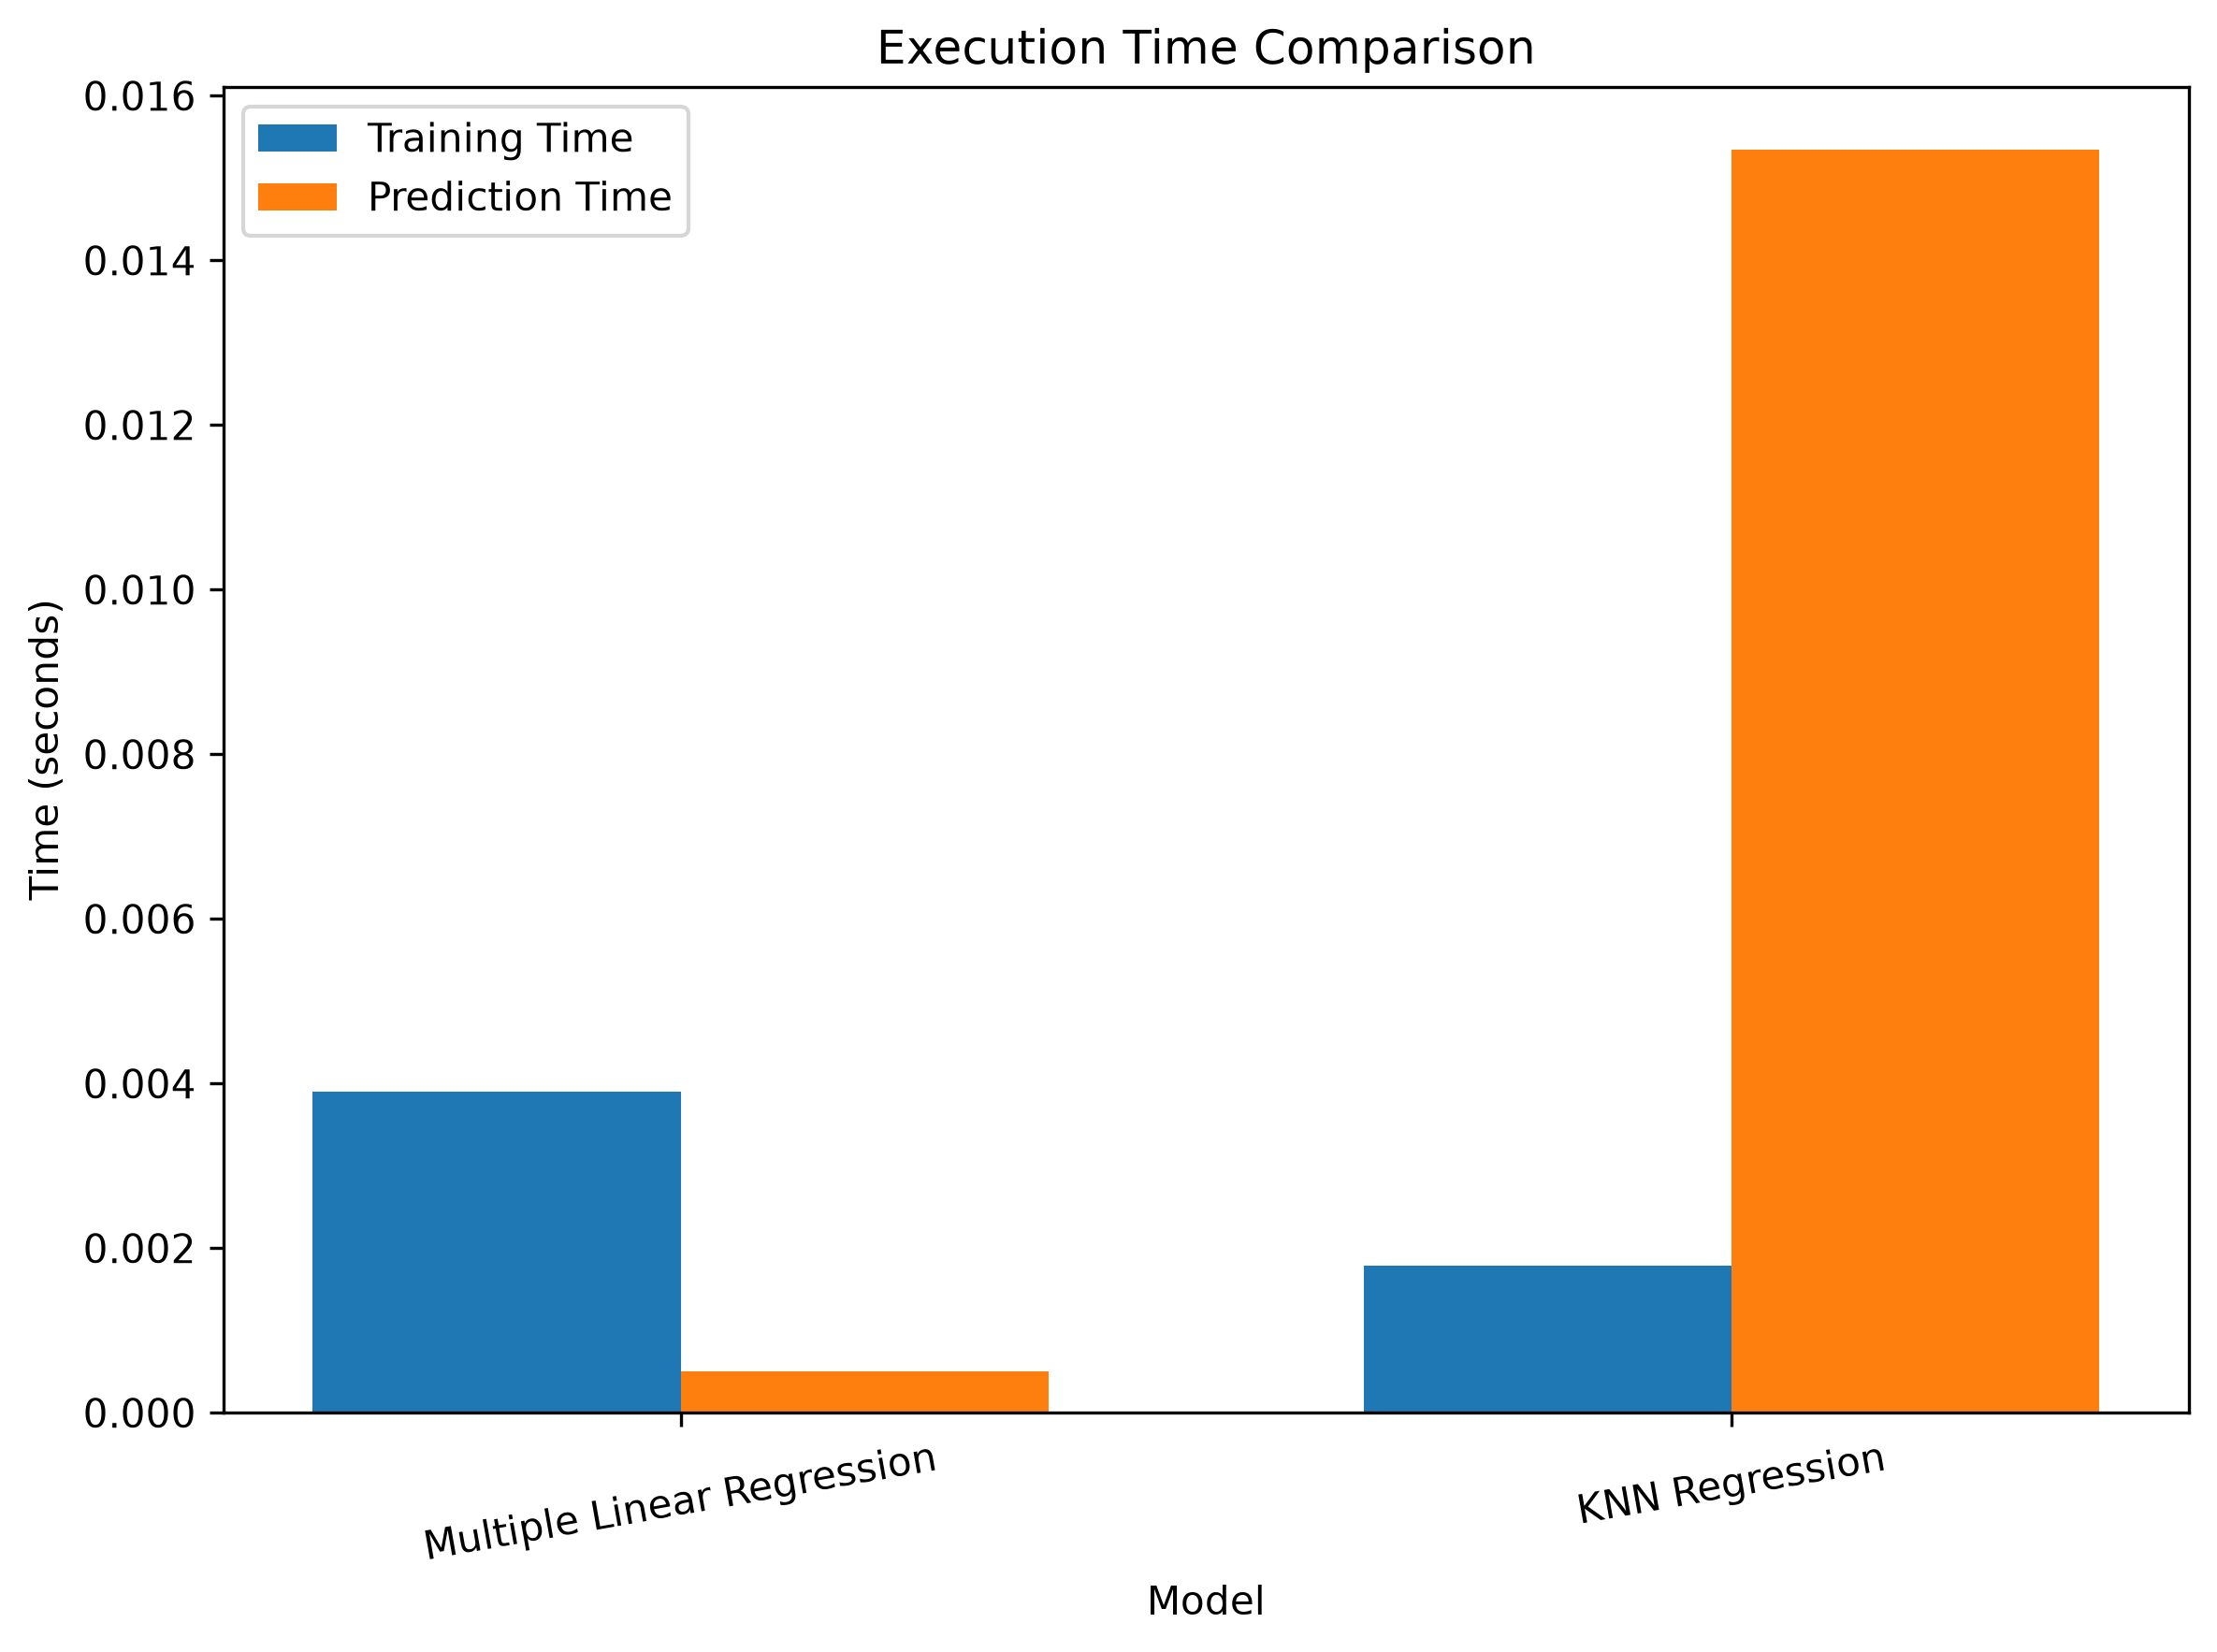

knn_actual_vs_predicted.png


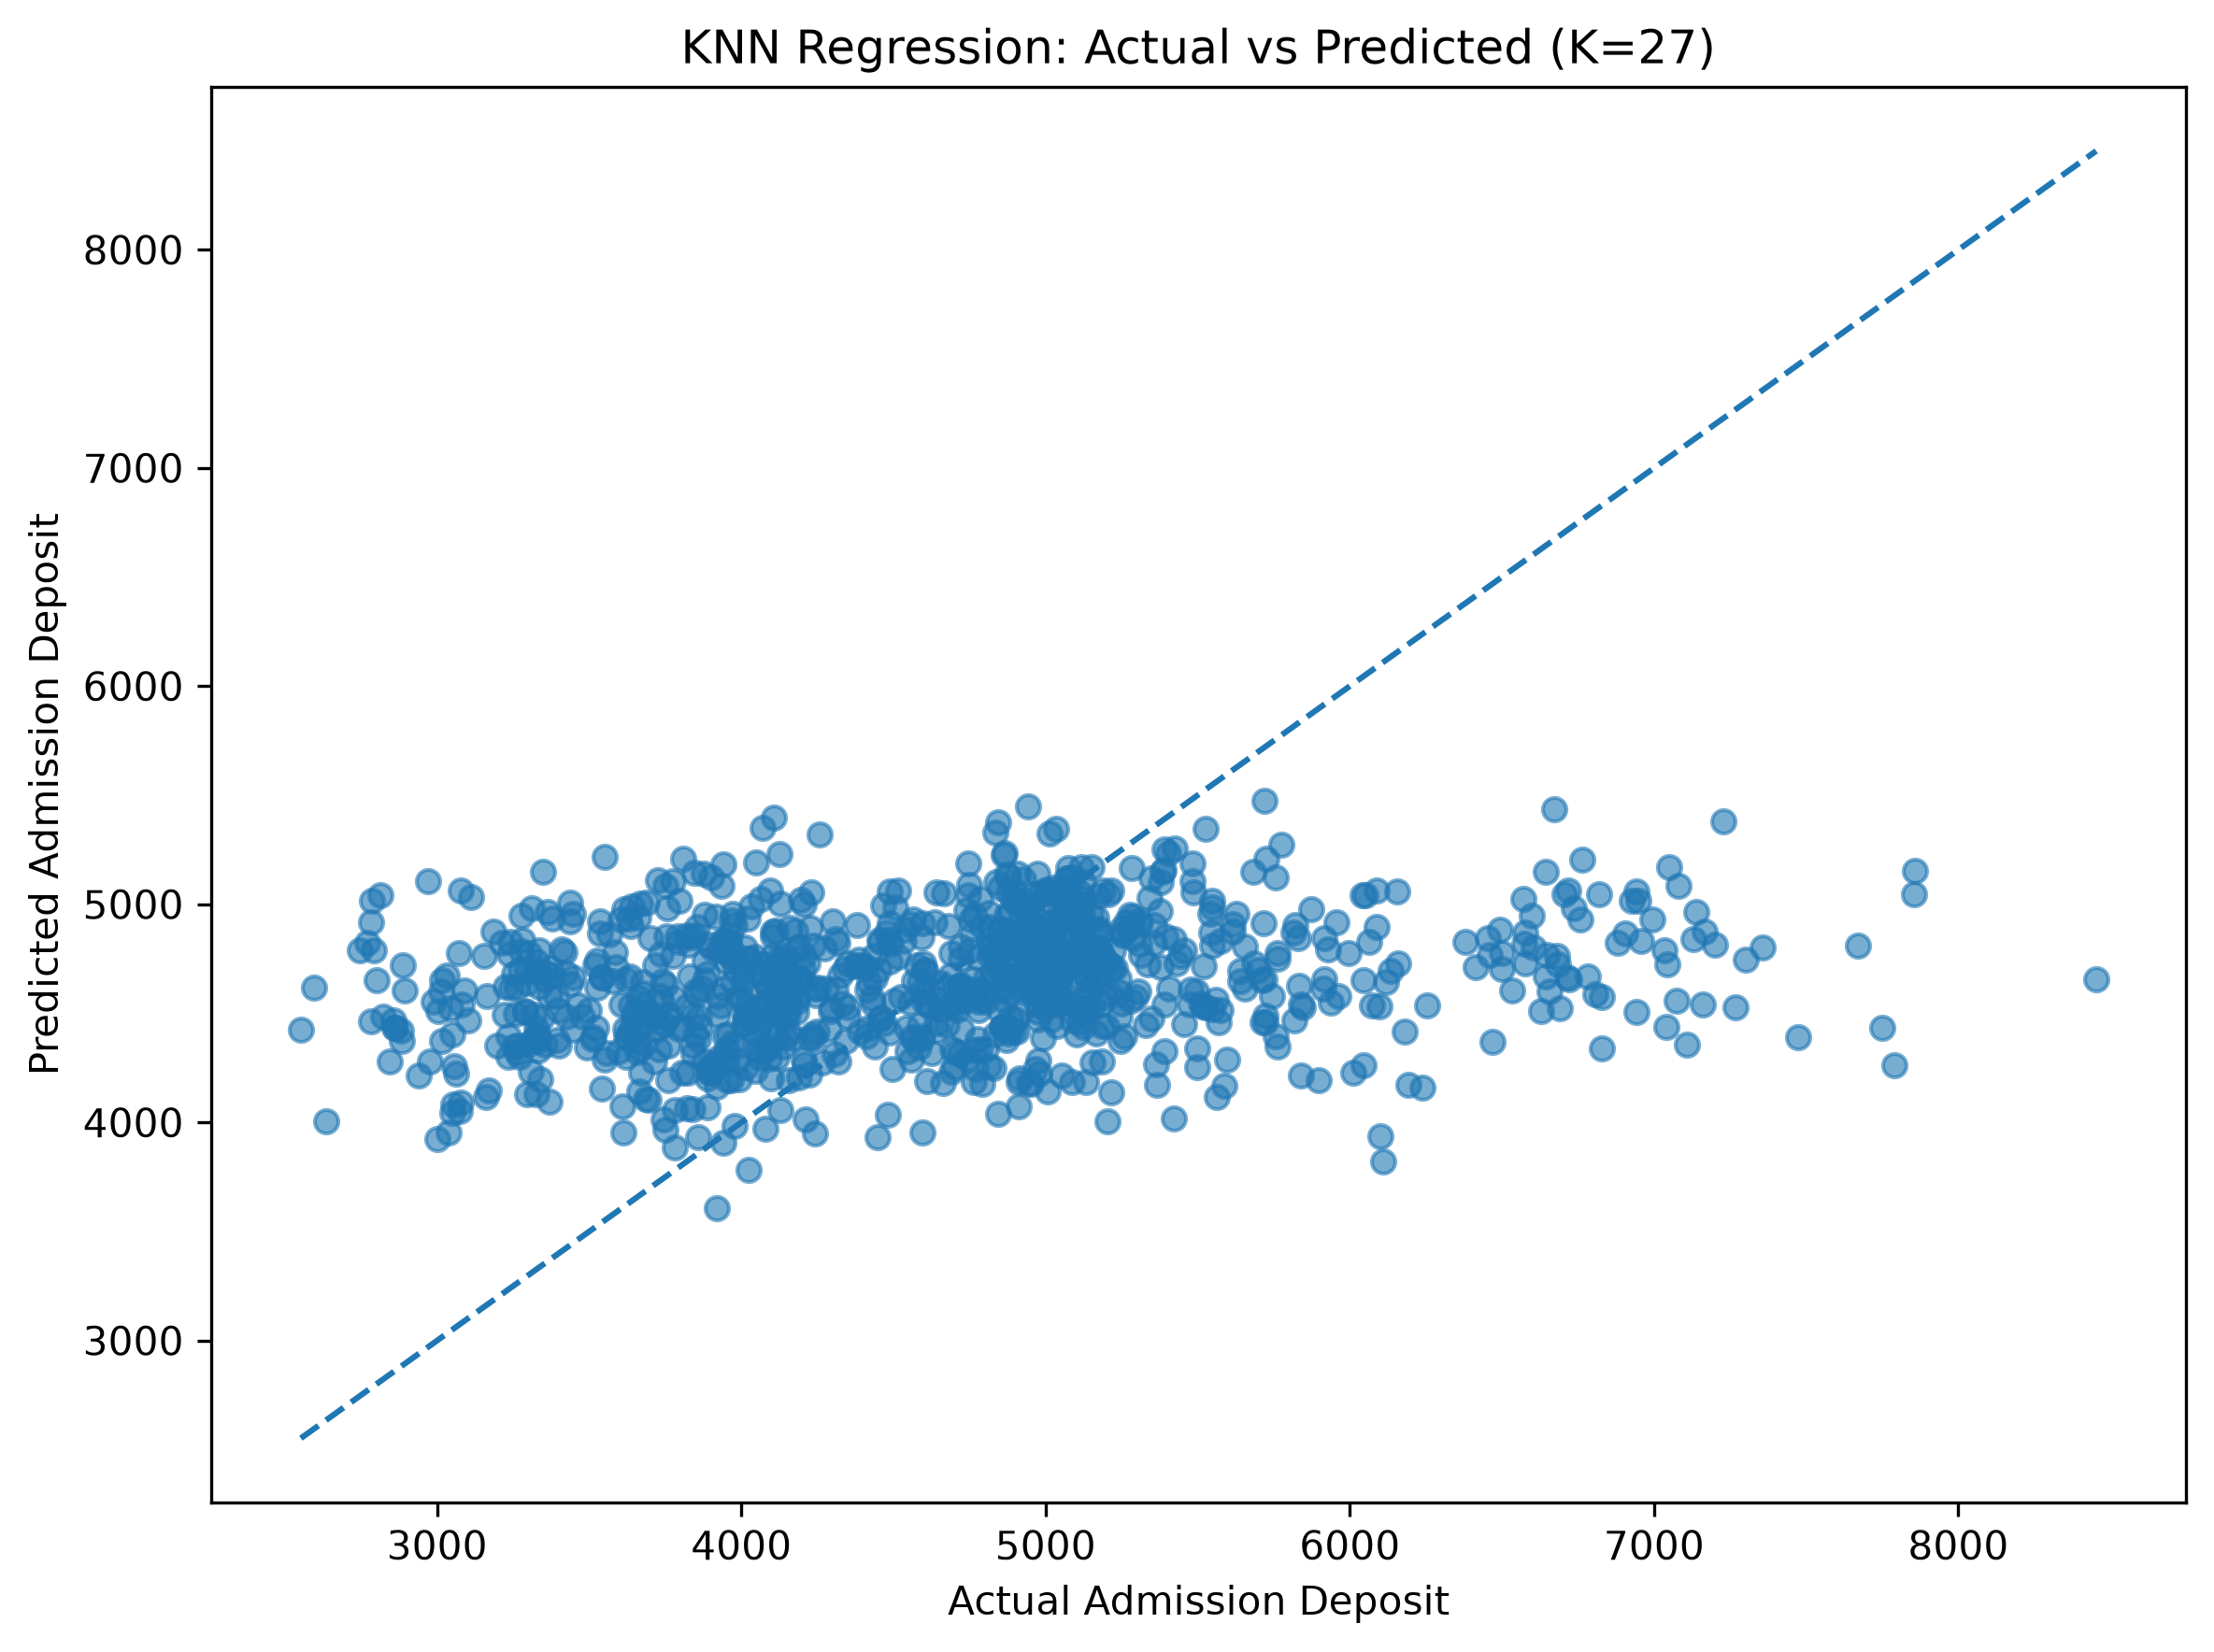

knn_k_vs_rmse.png


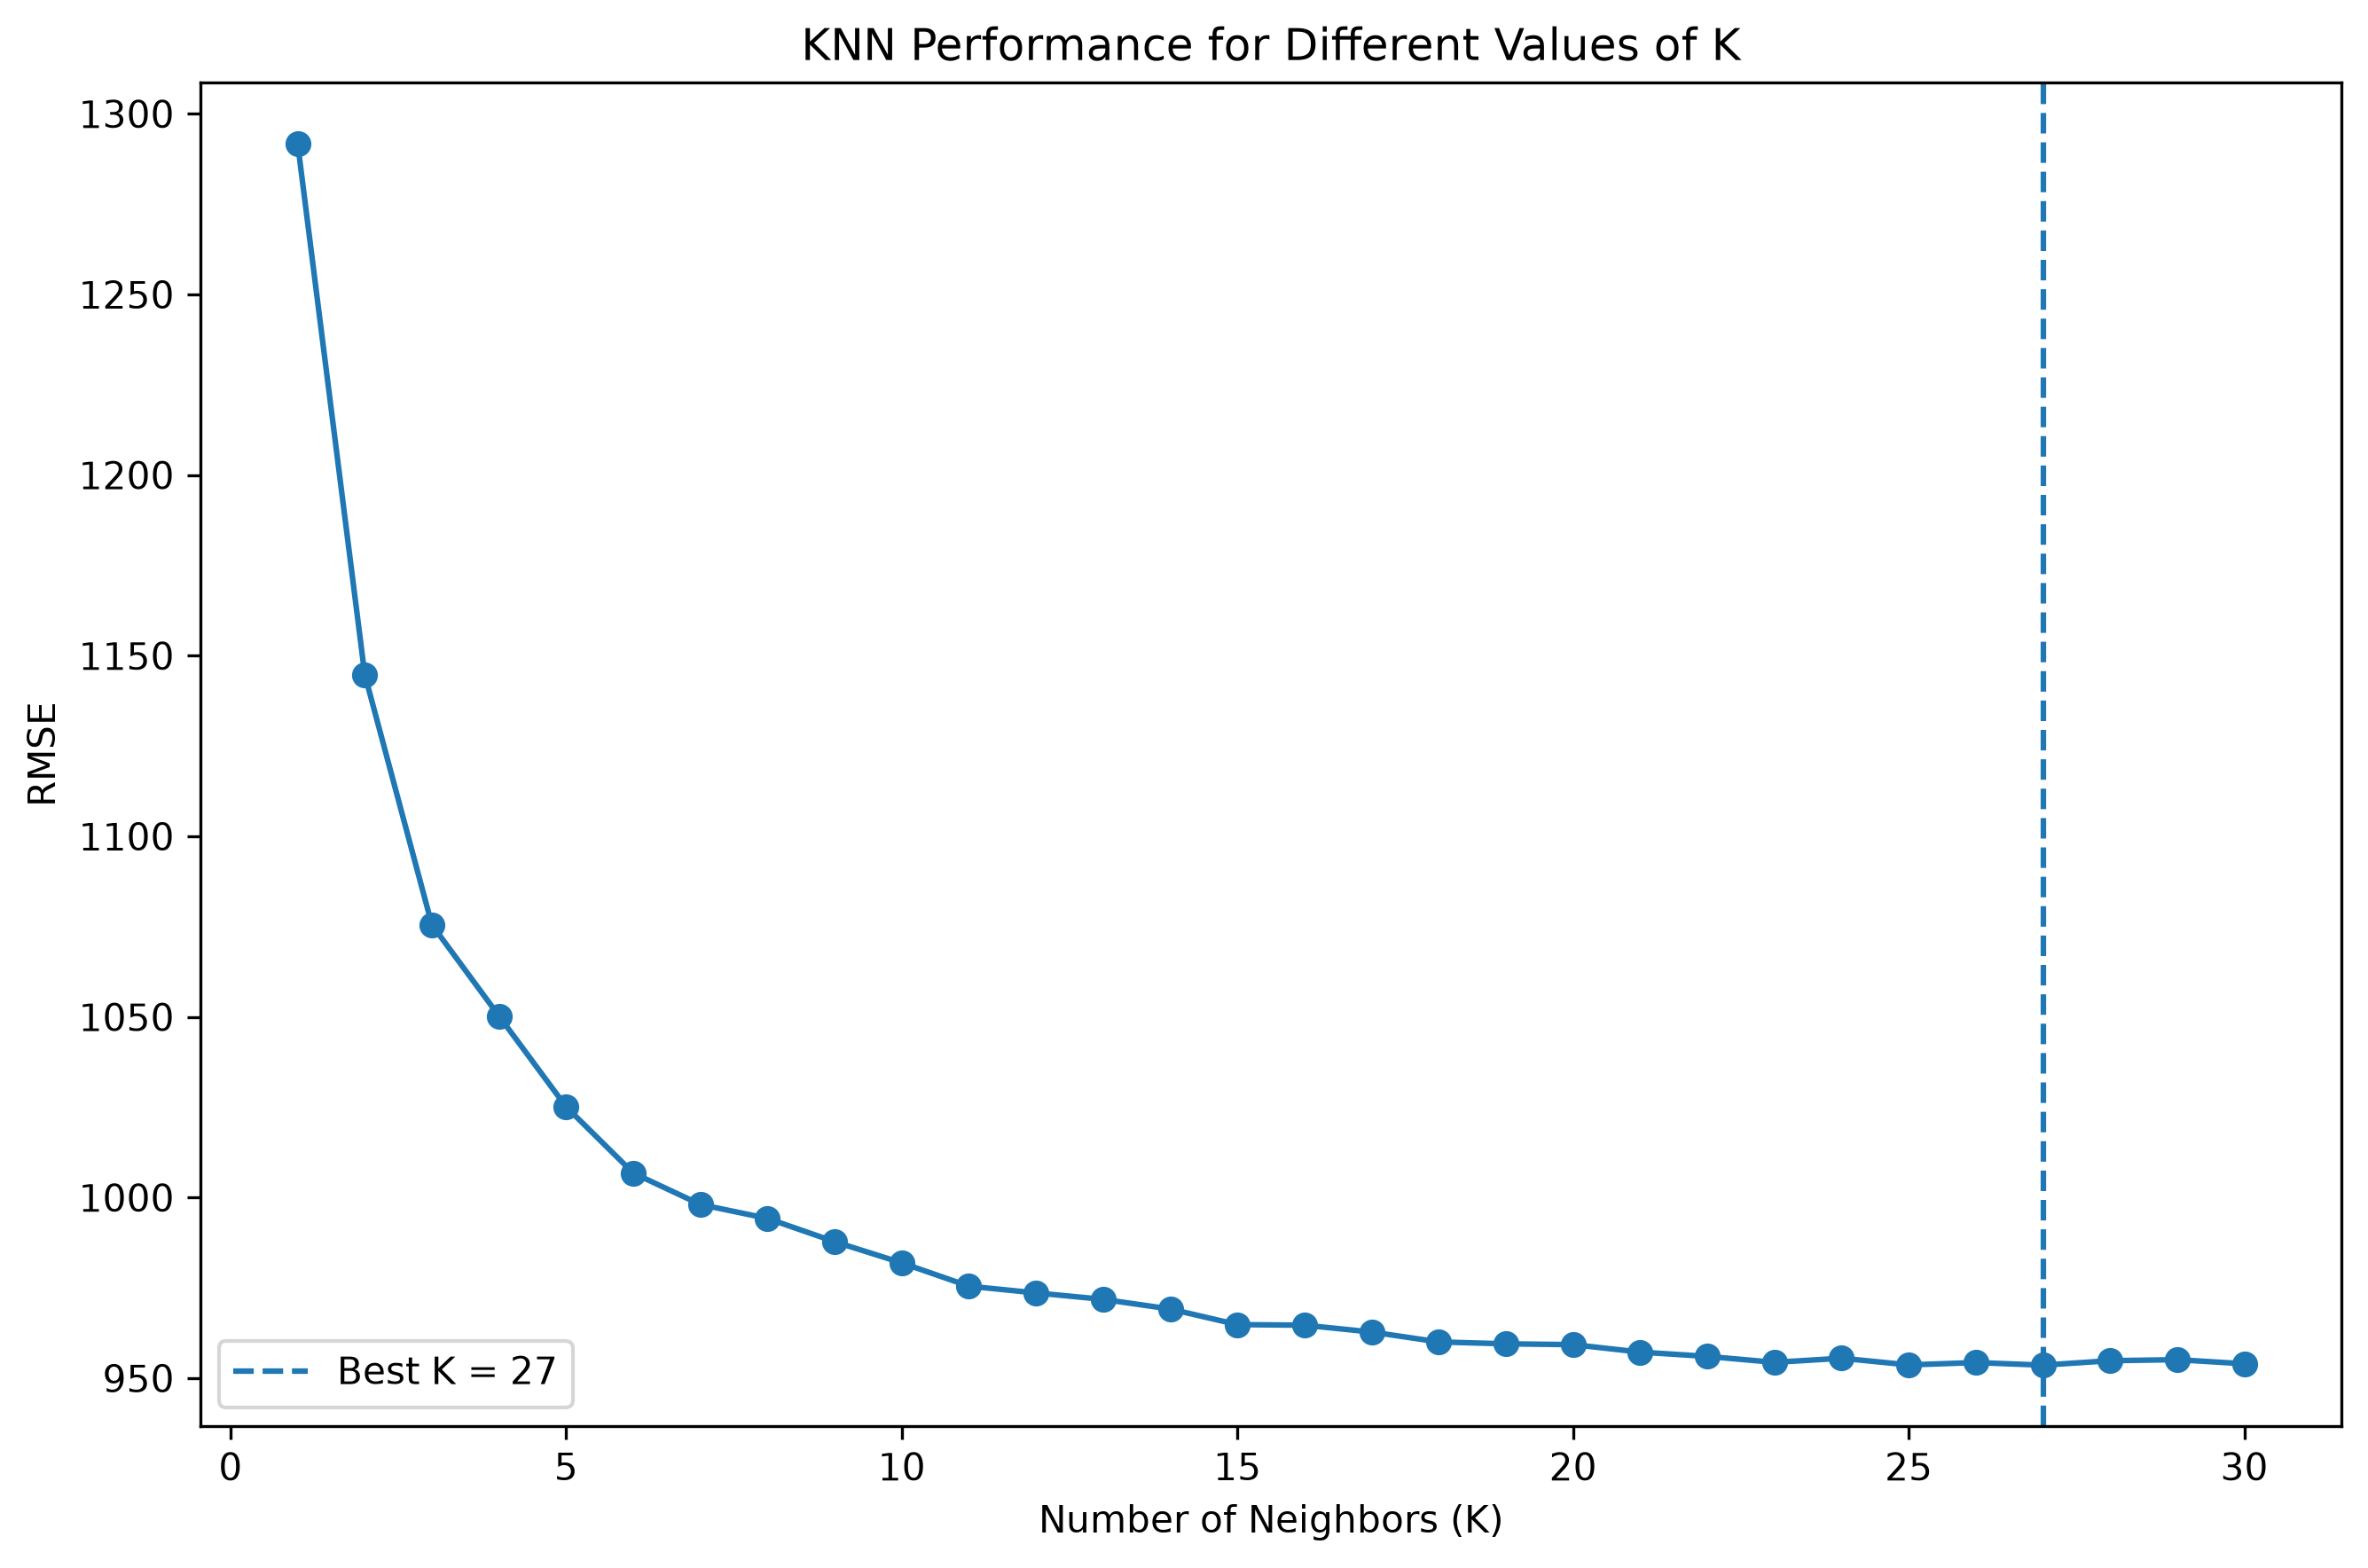

knn_residual_plot.png


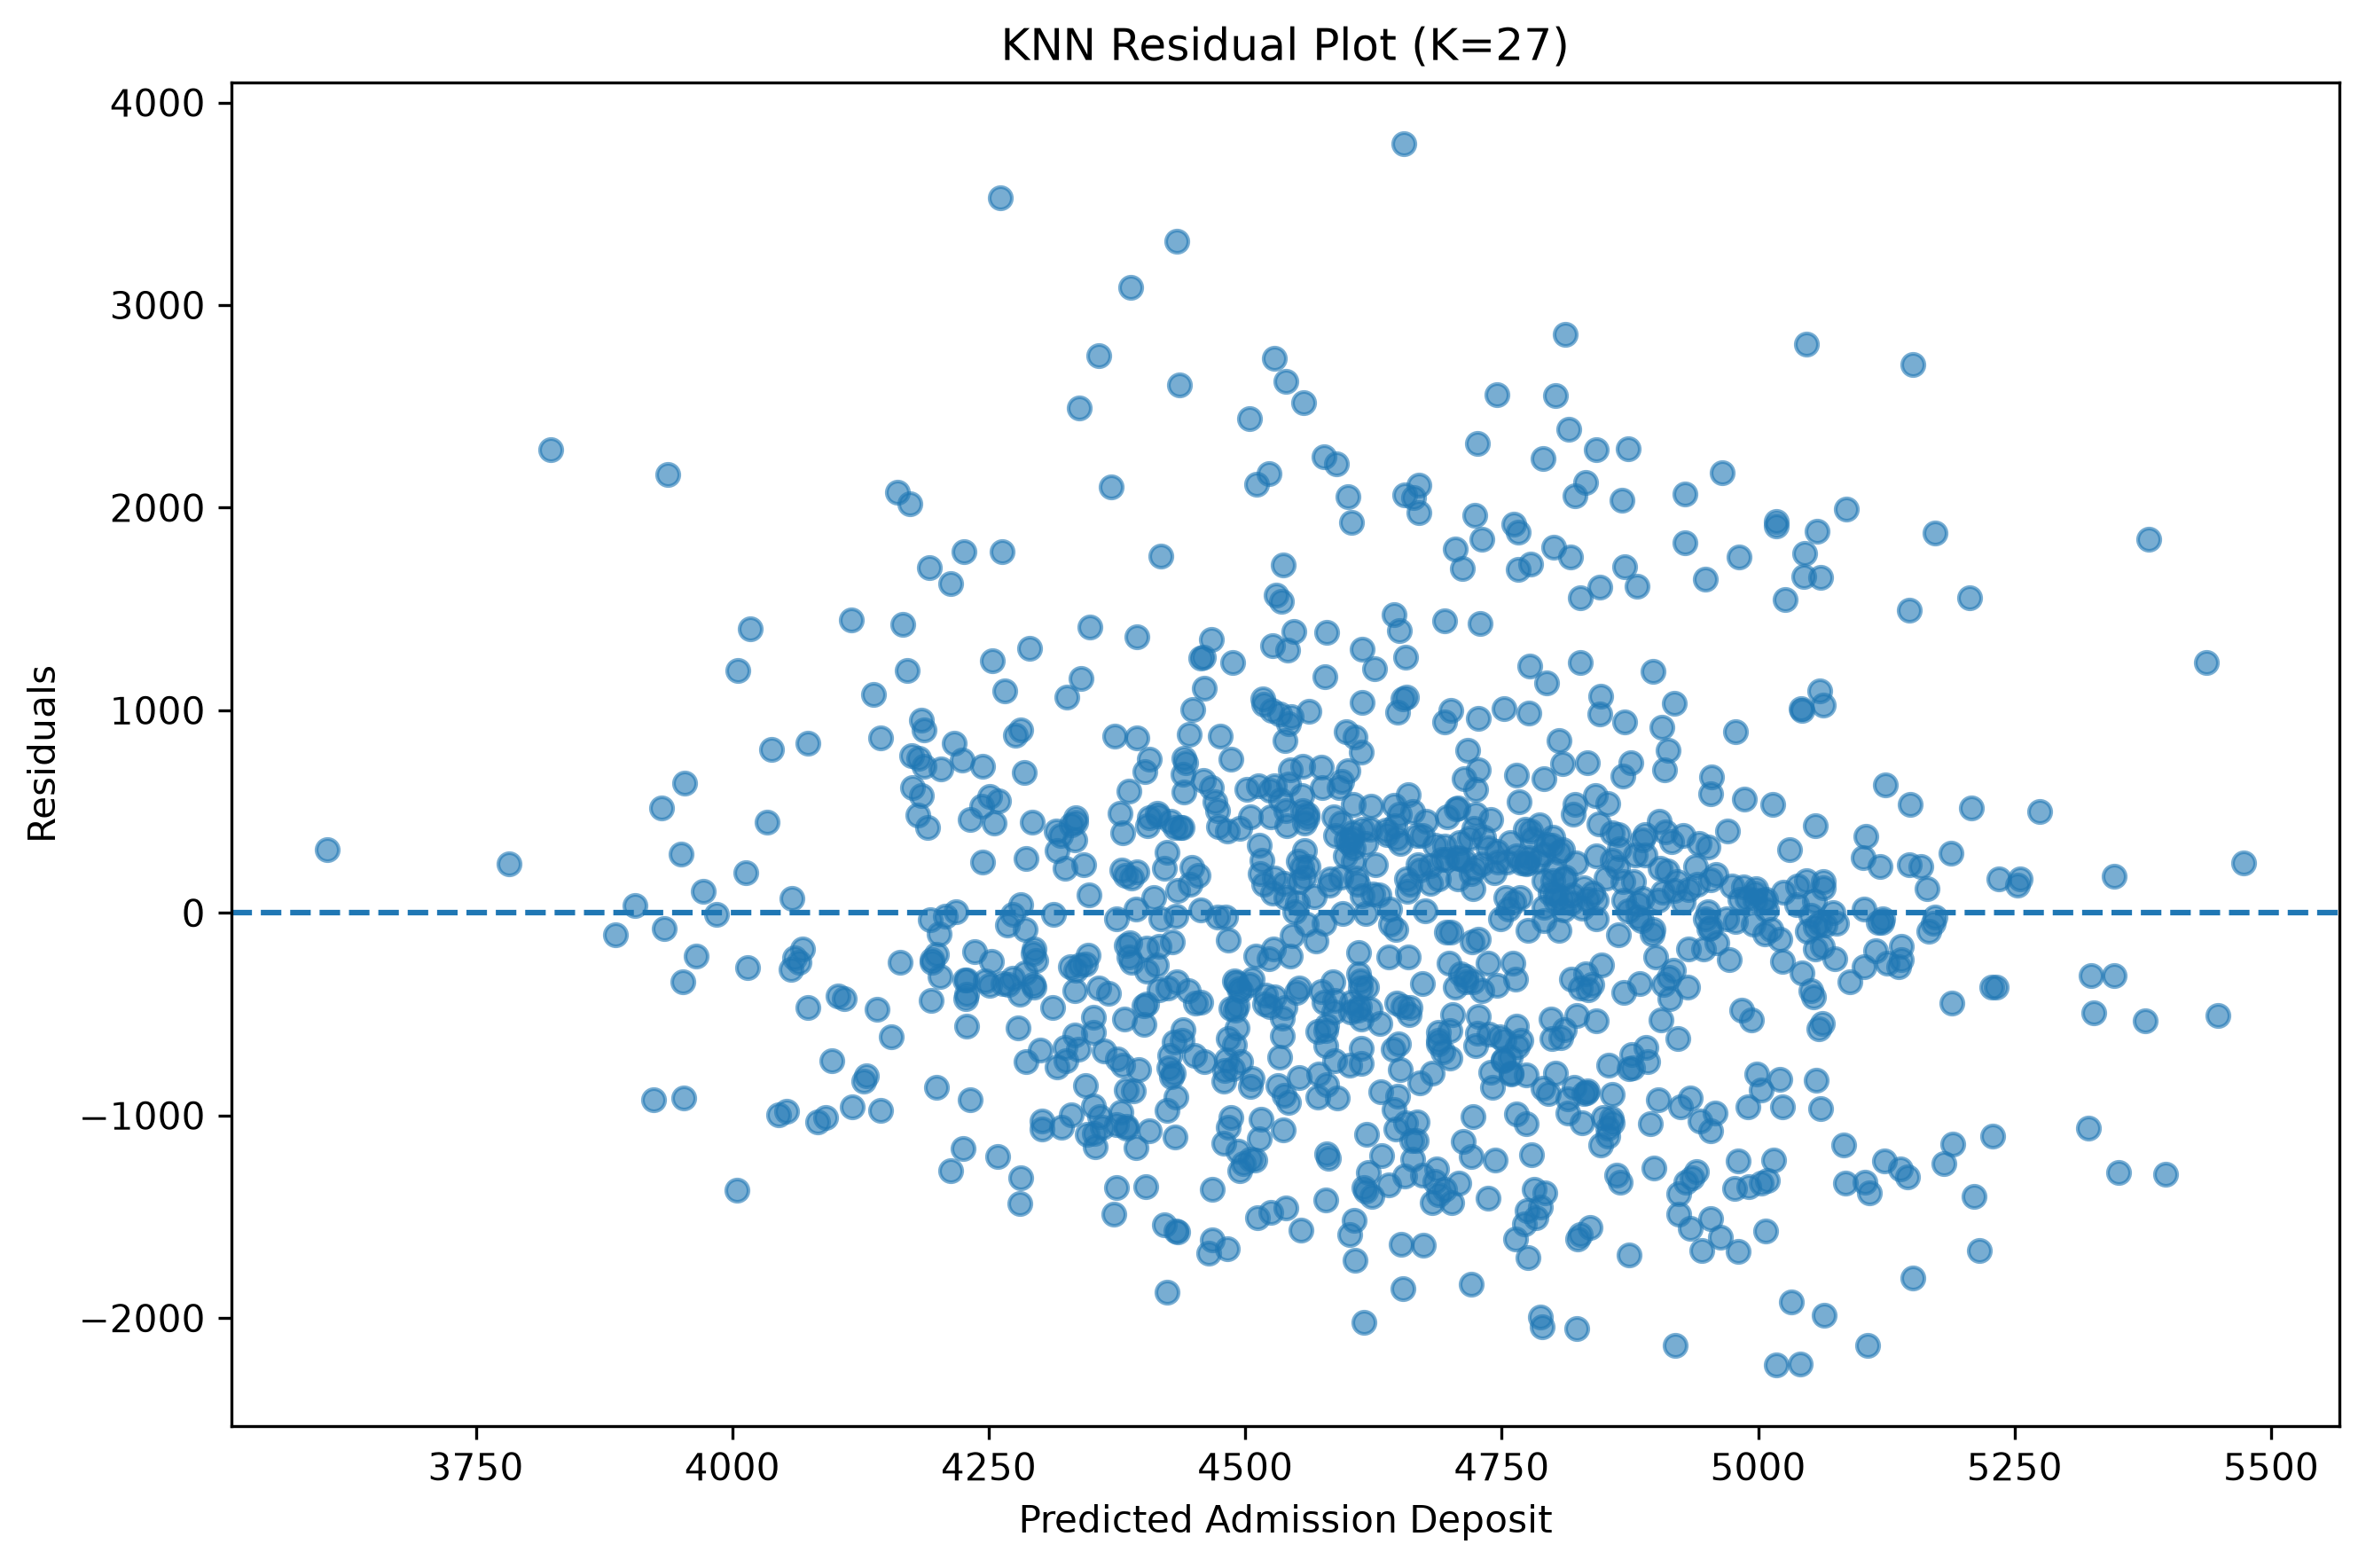

mae_comparison.png


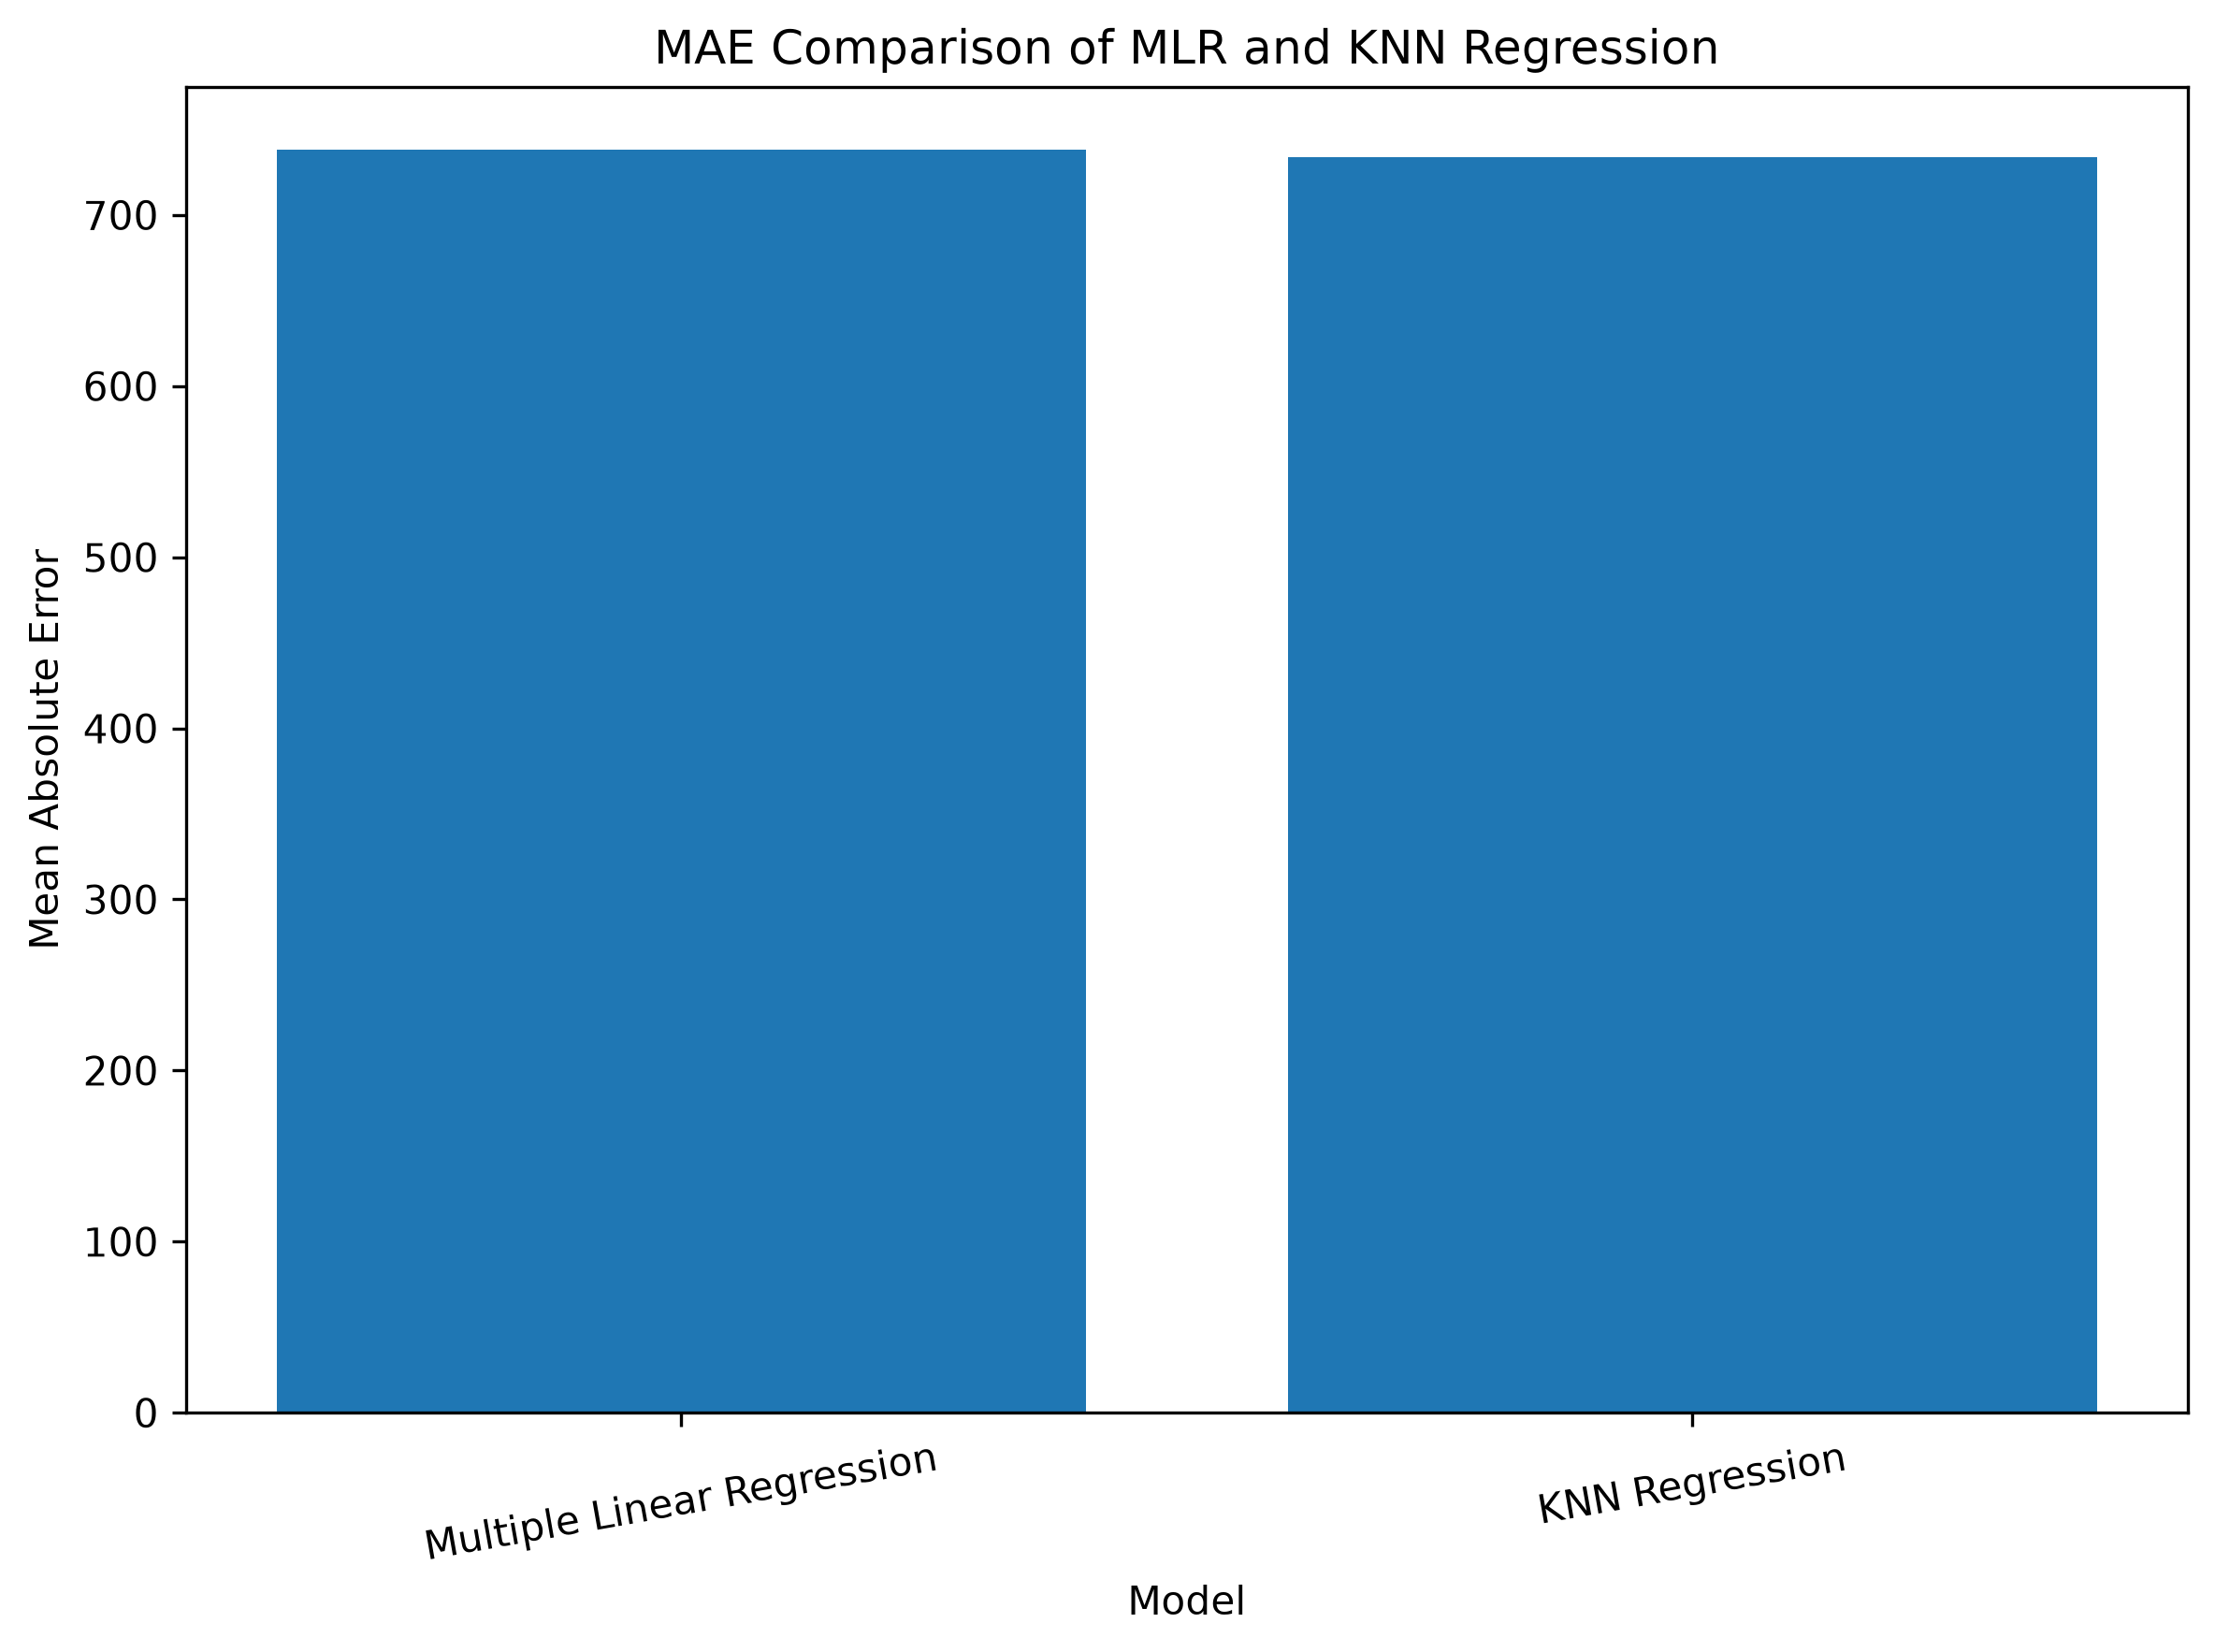

mlr_actual_vs_predicted.png


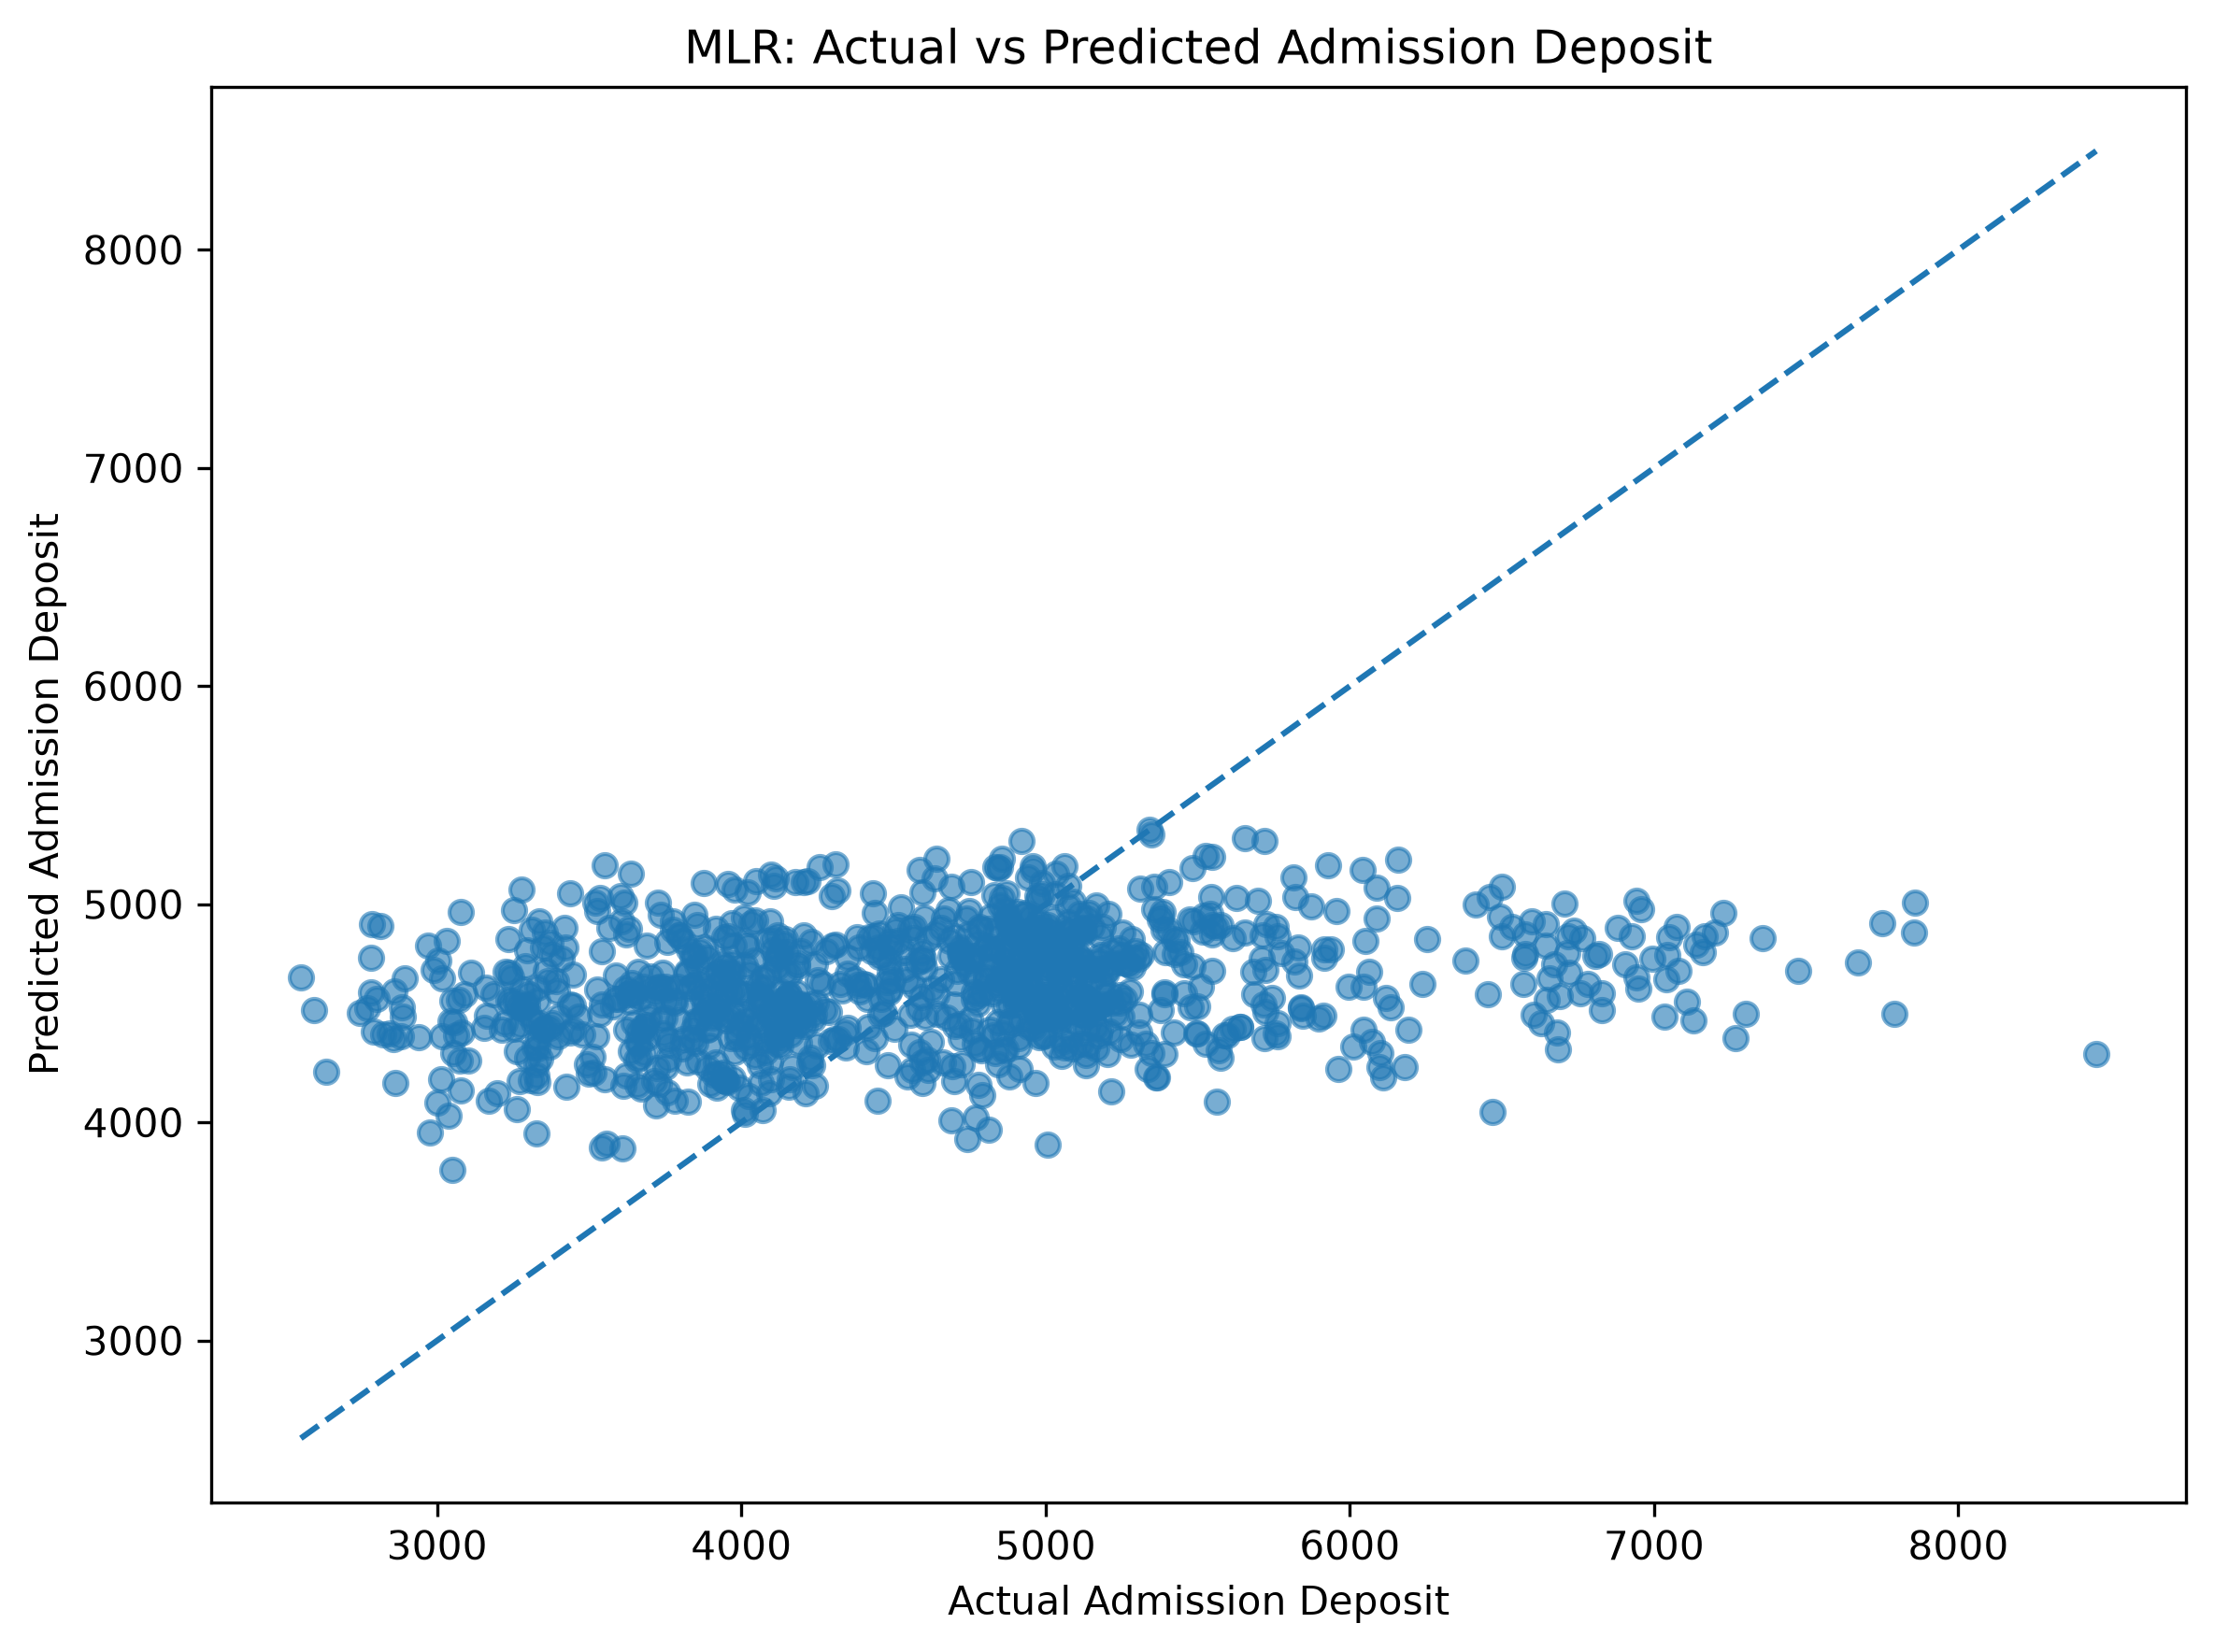

mlr_residual_plot.png


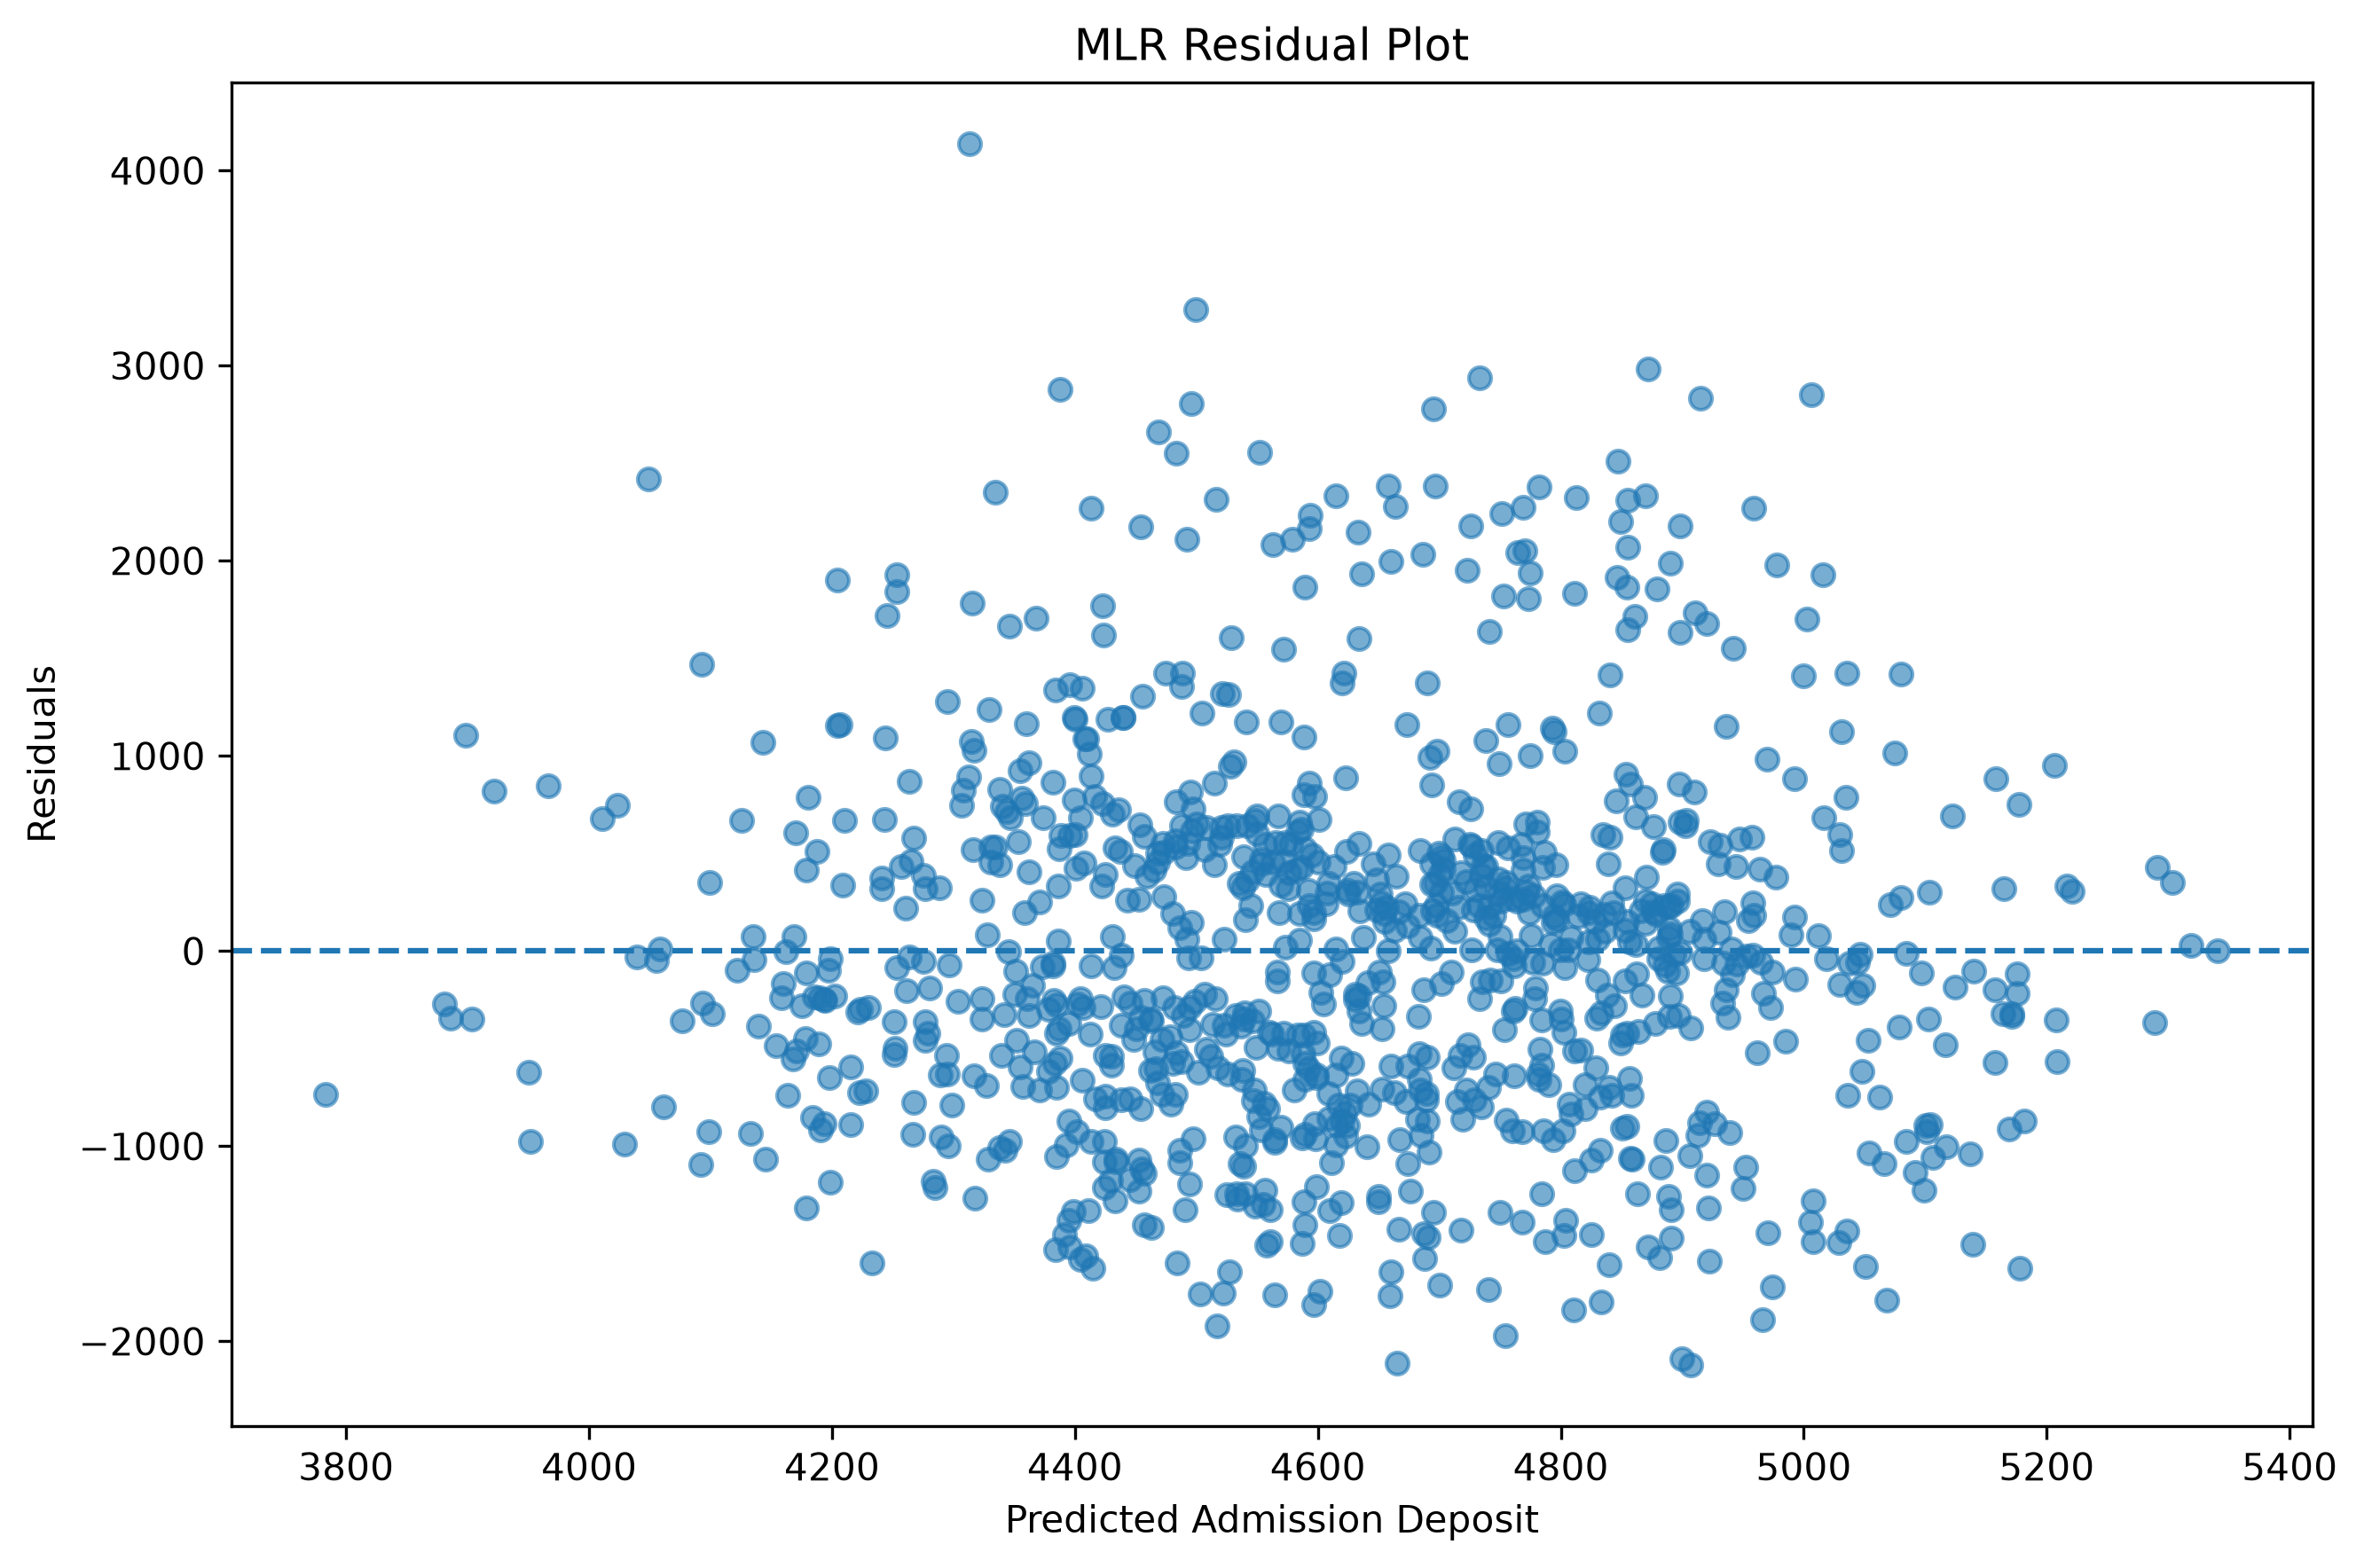

model_performance_comparison.png


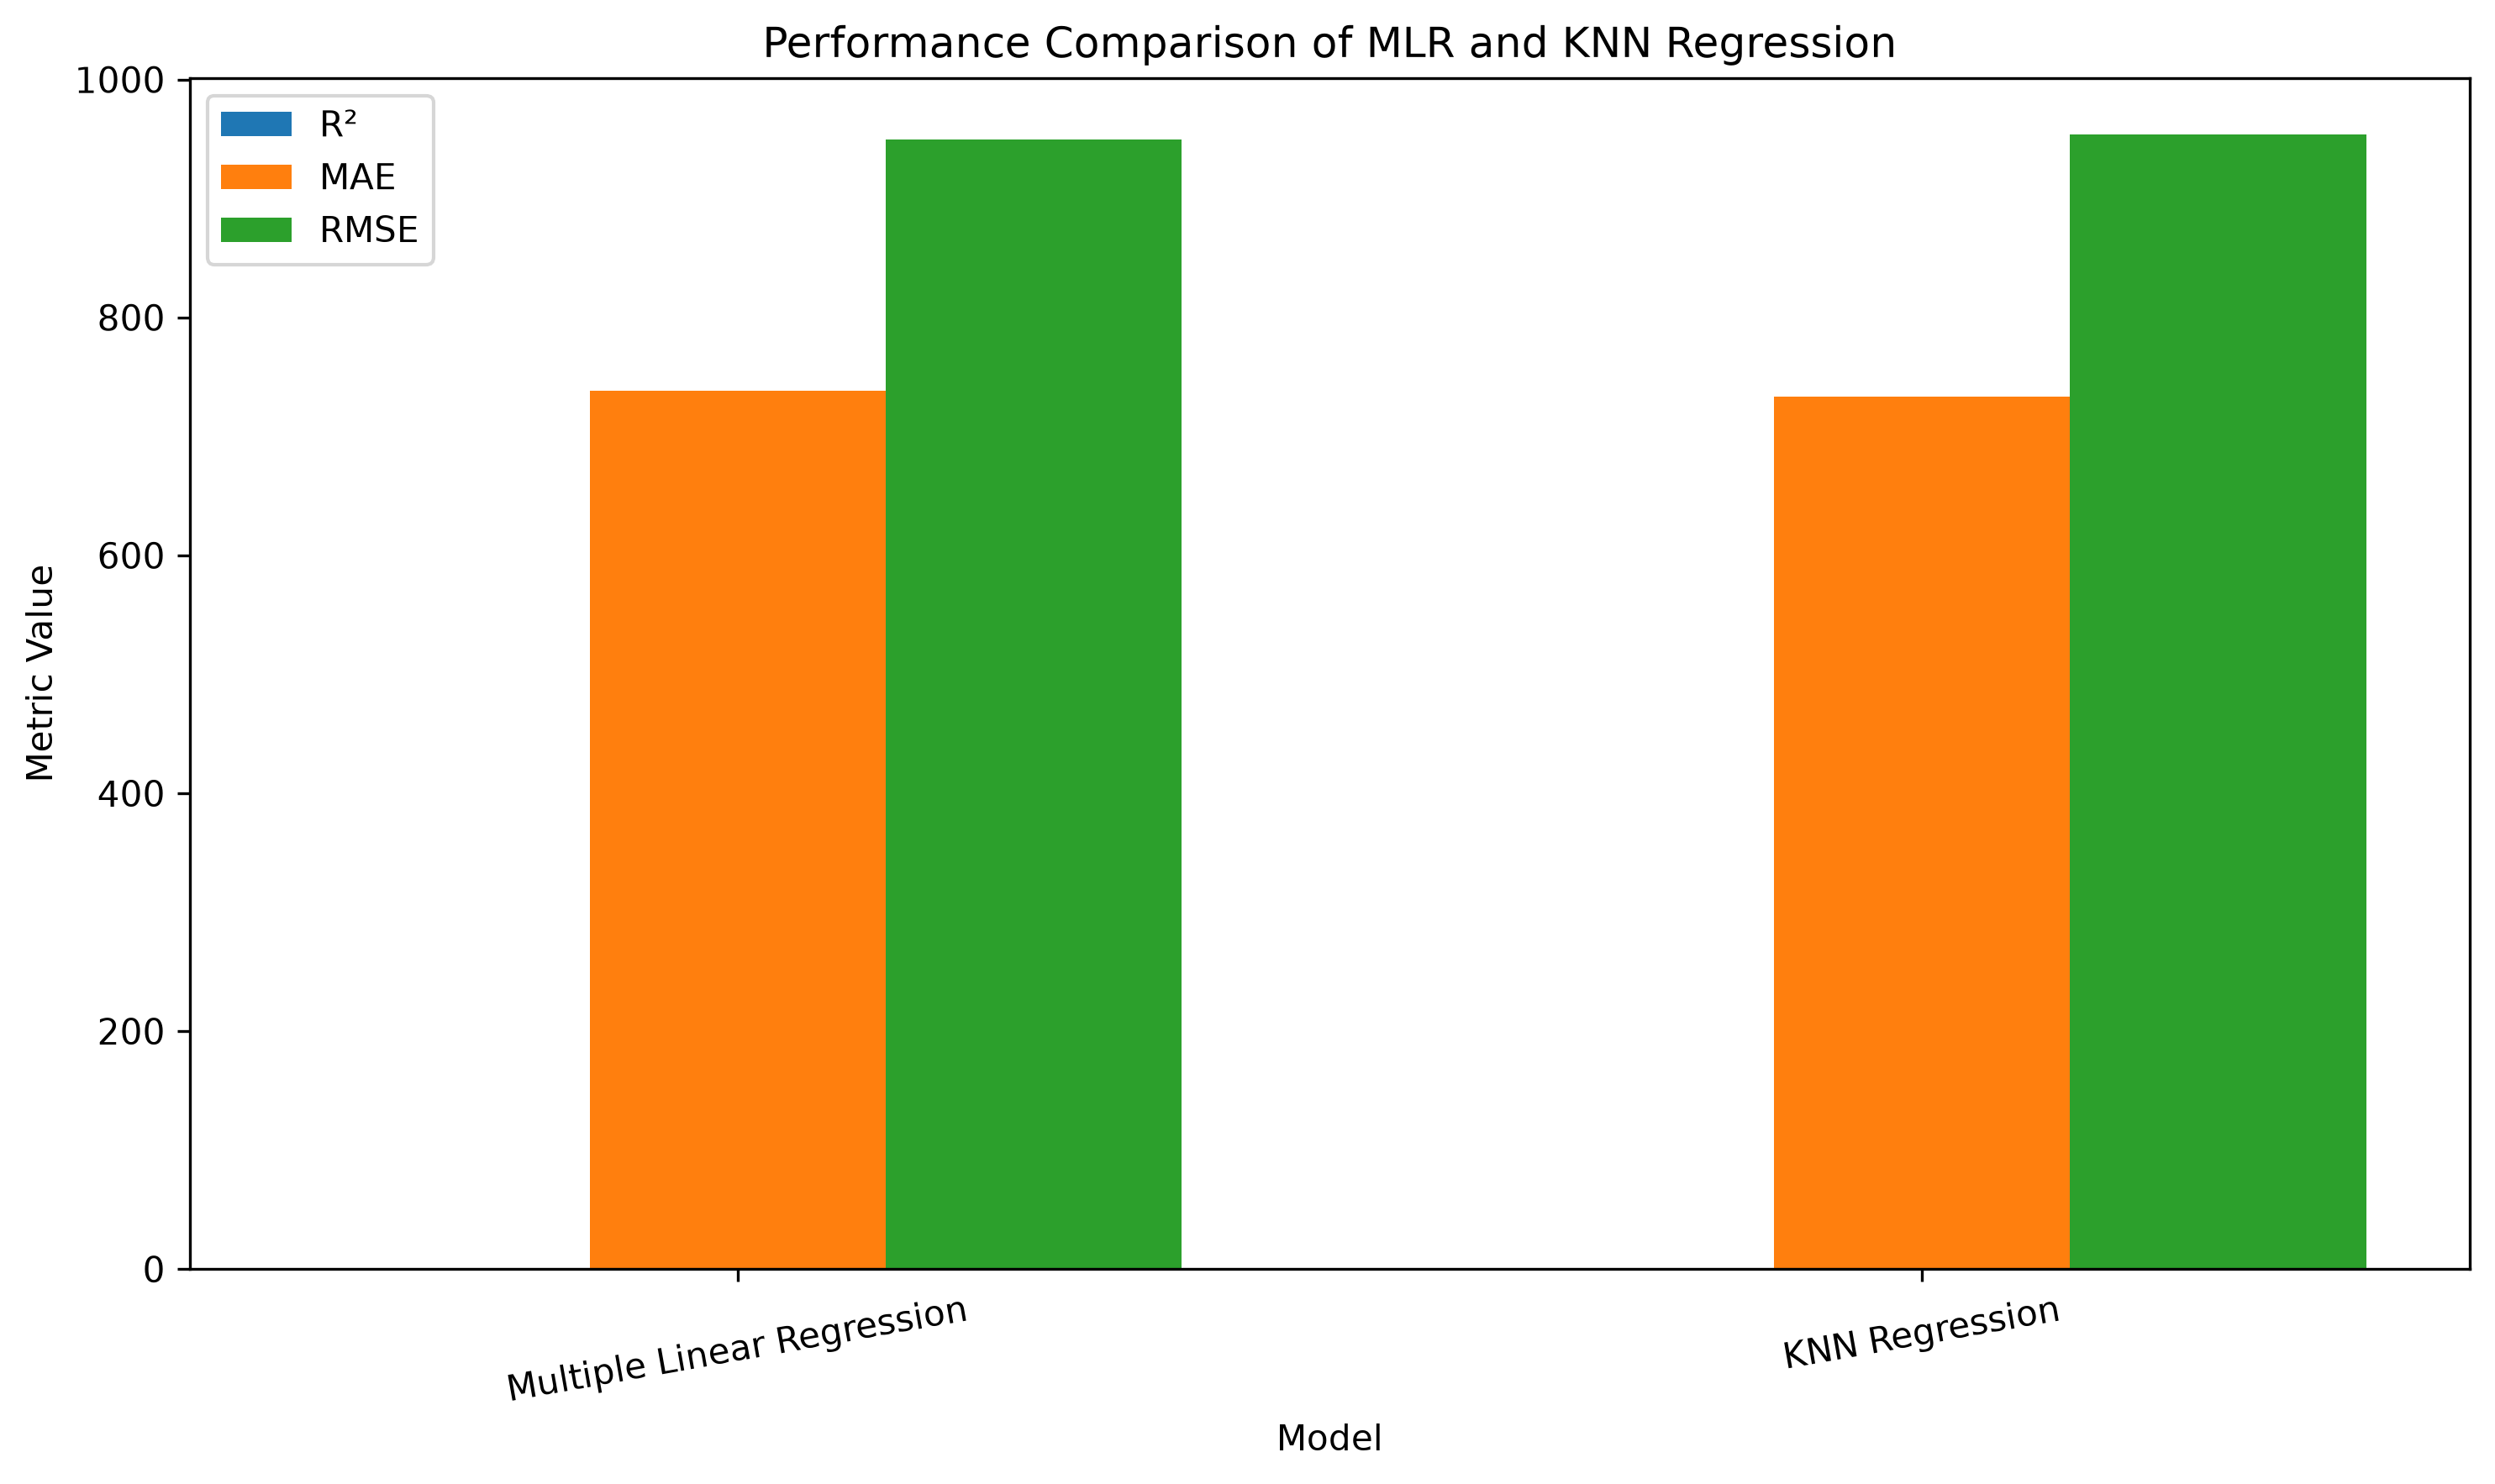

r2_comparison.png


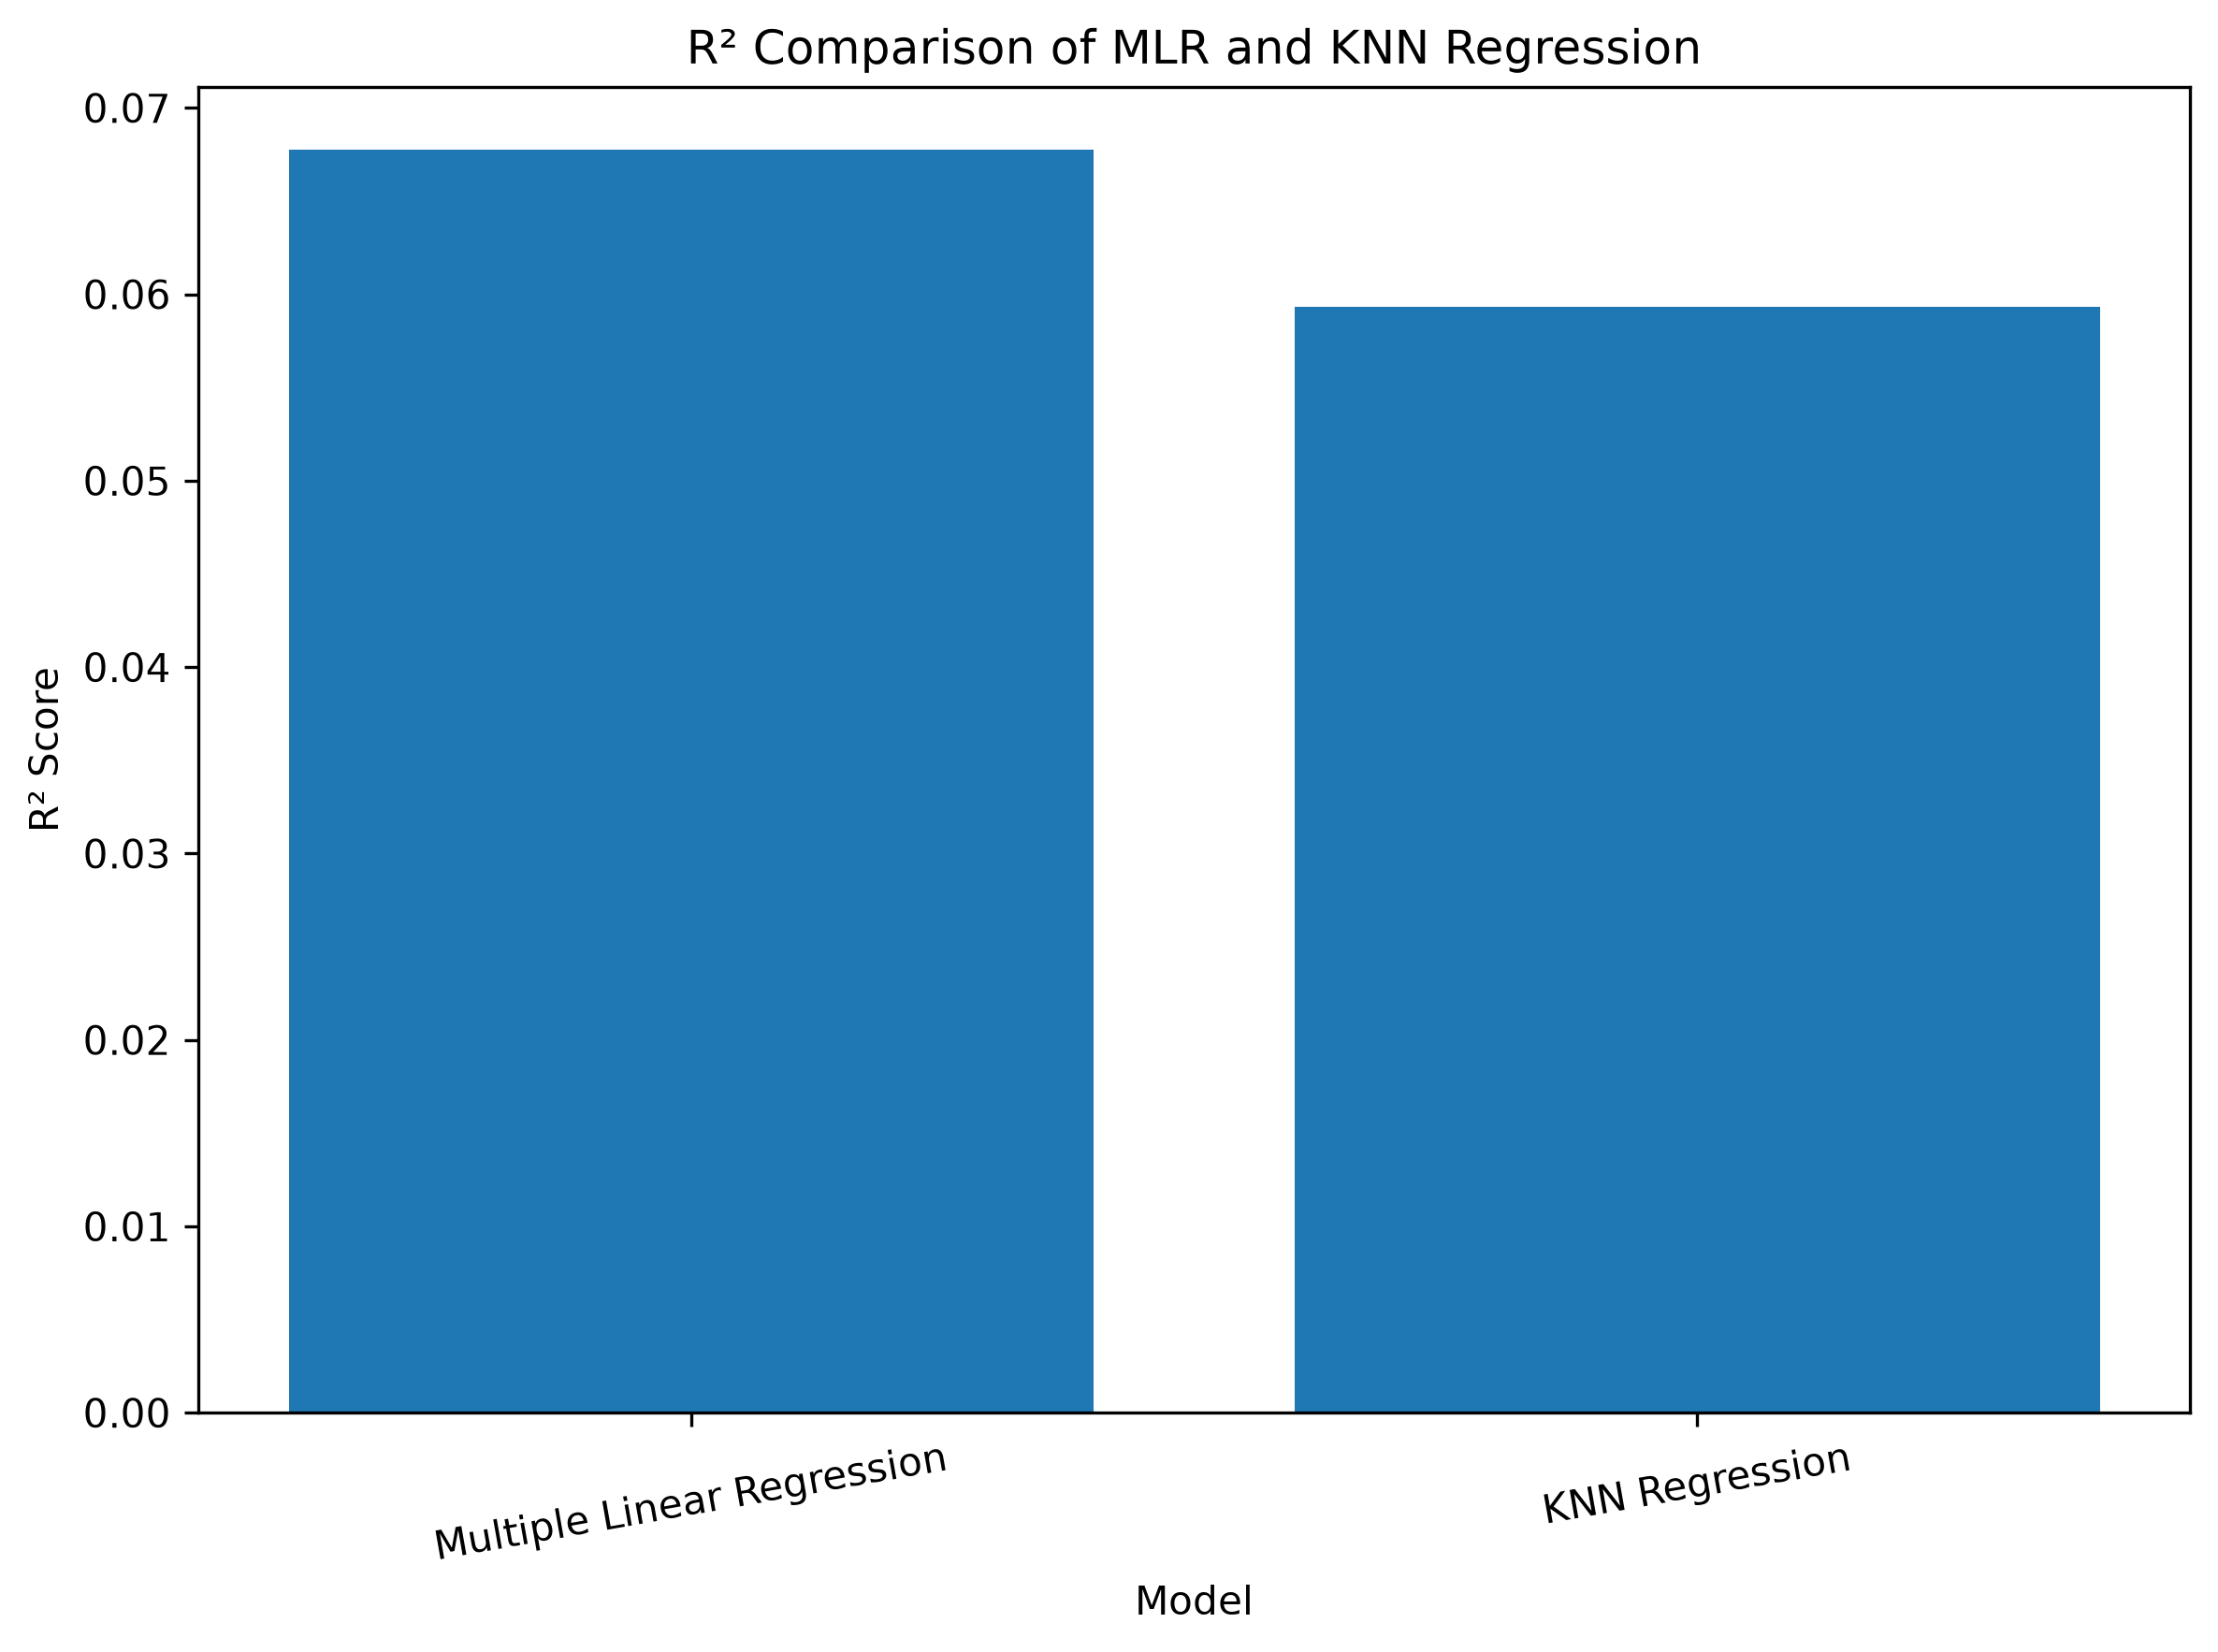

rmse_comparison.png


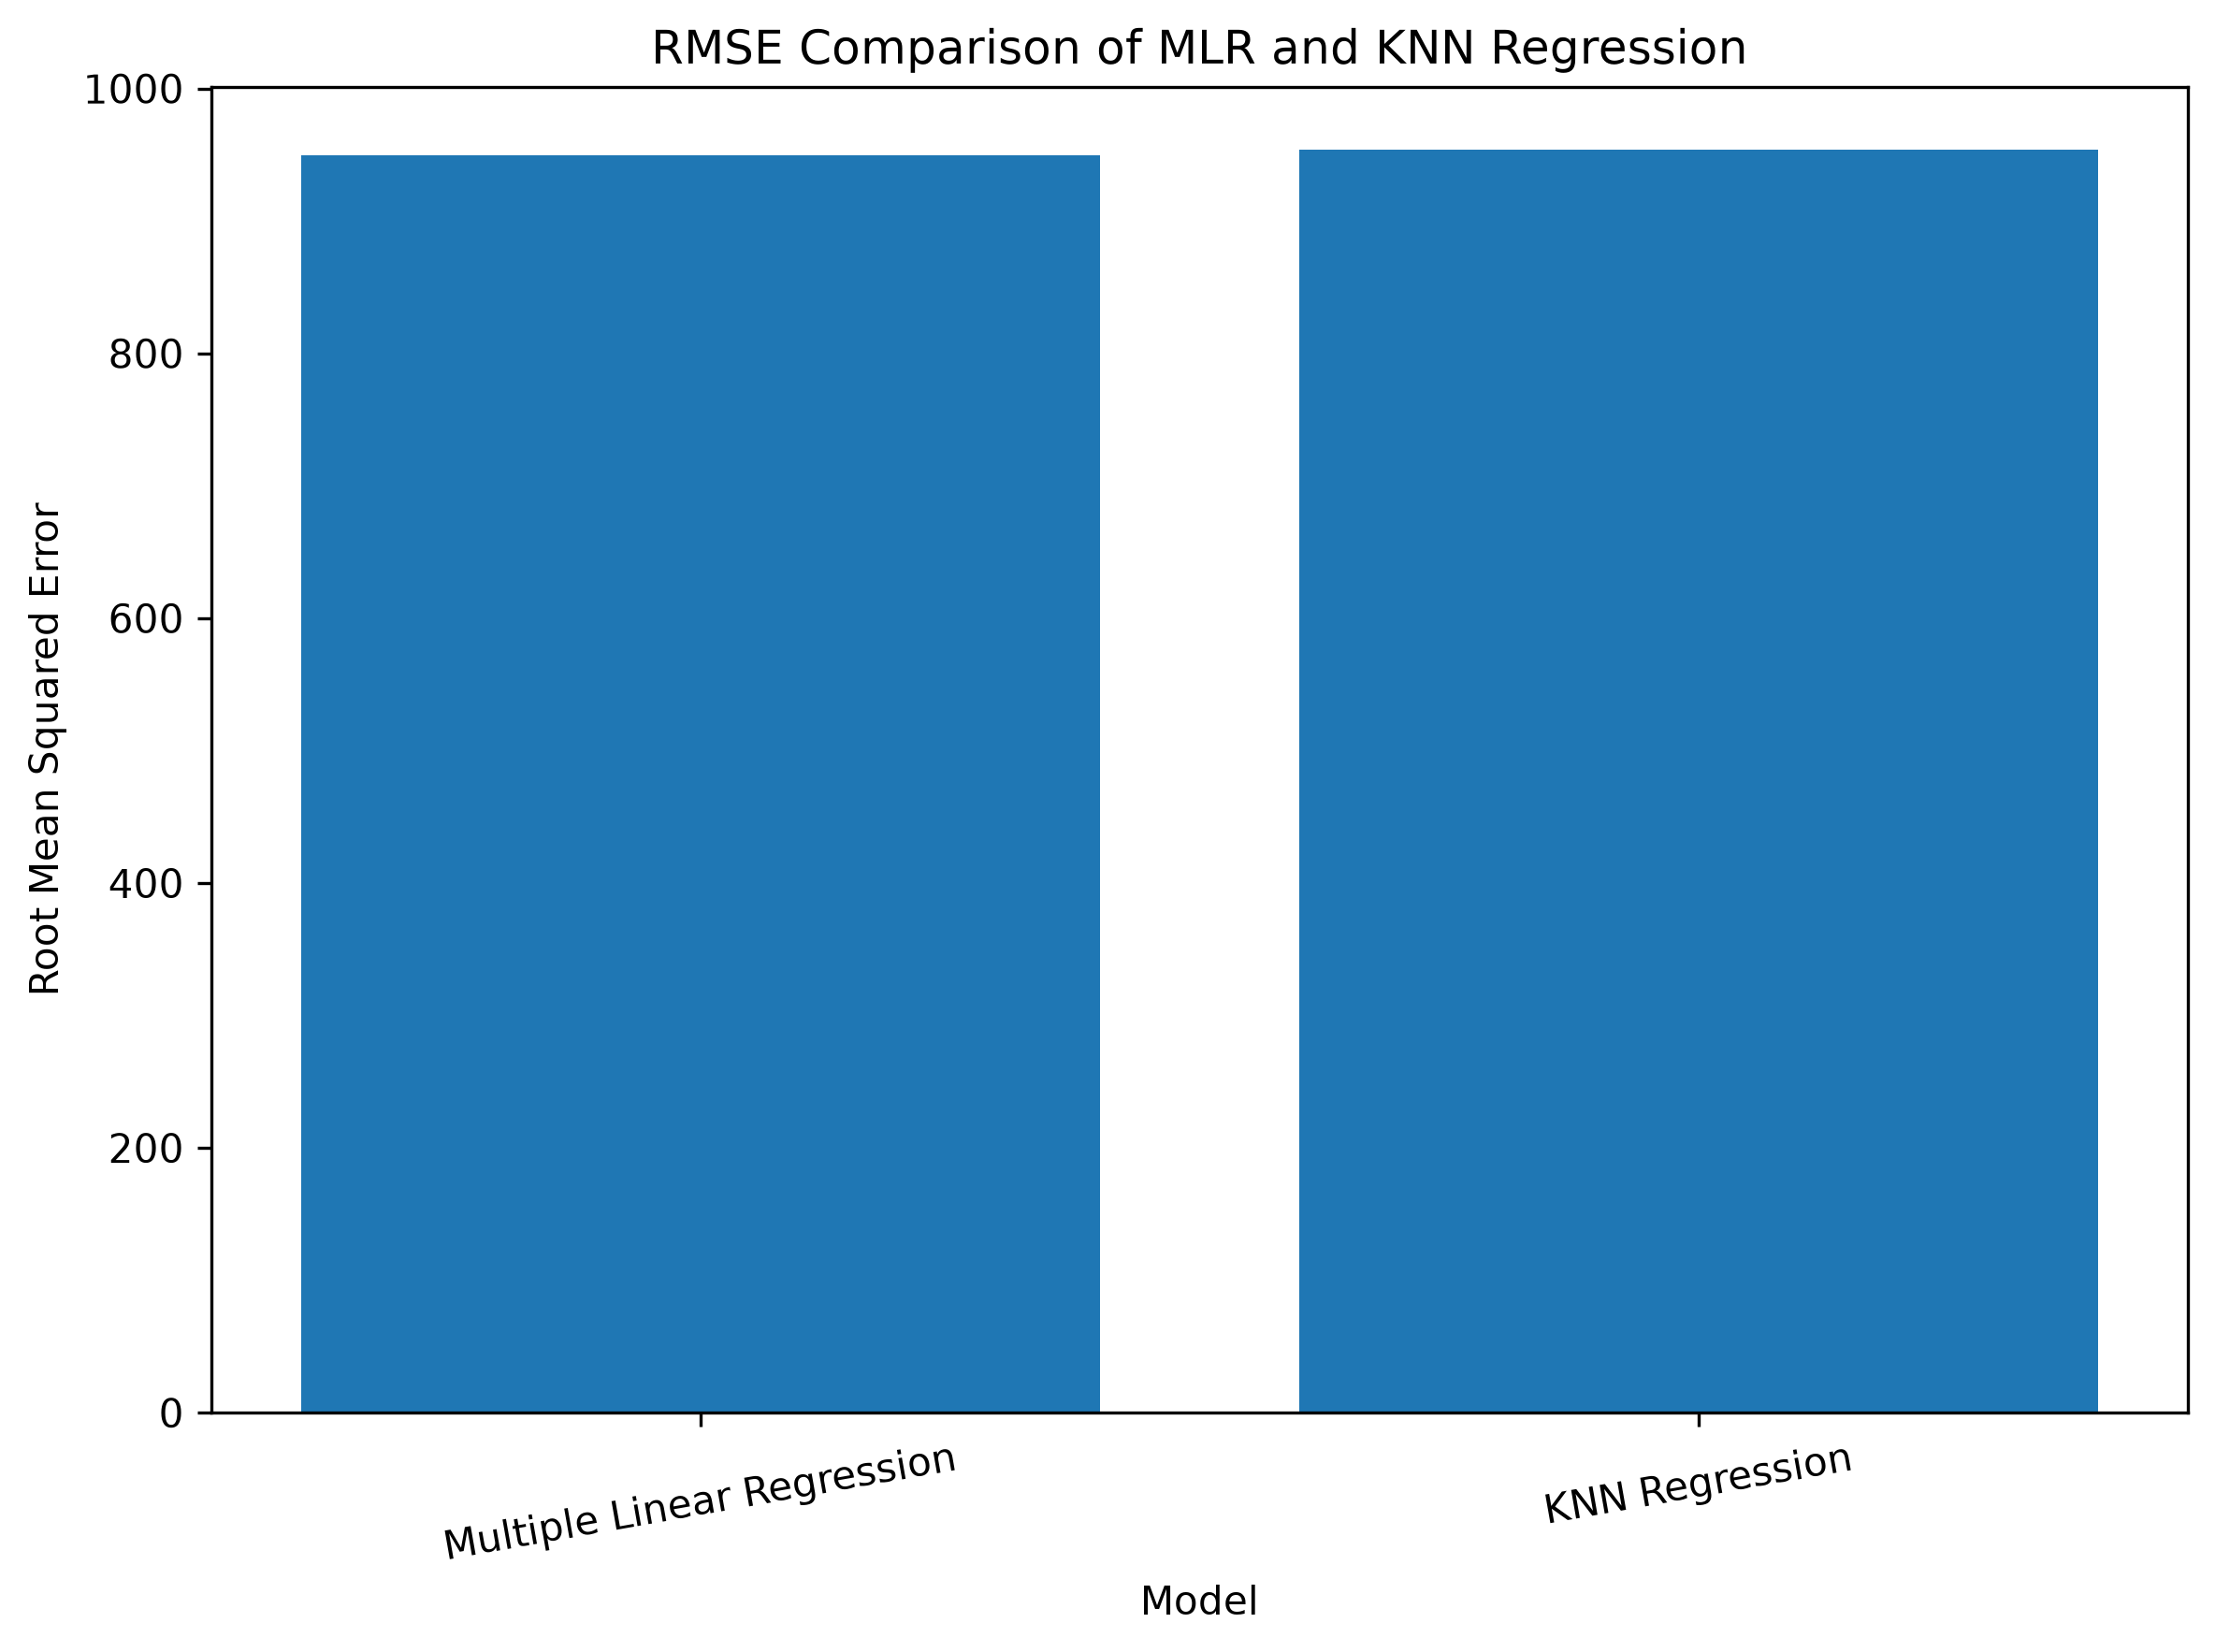

target_distribution.png


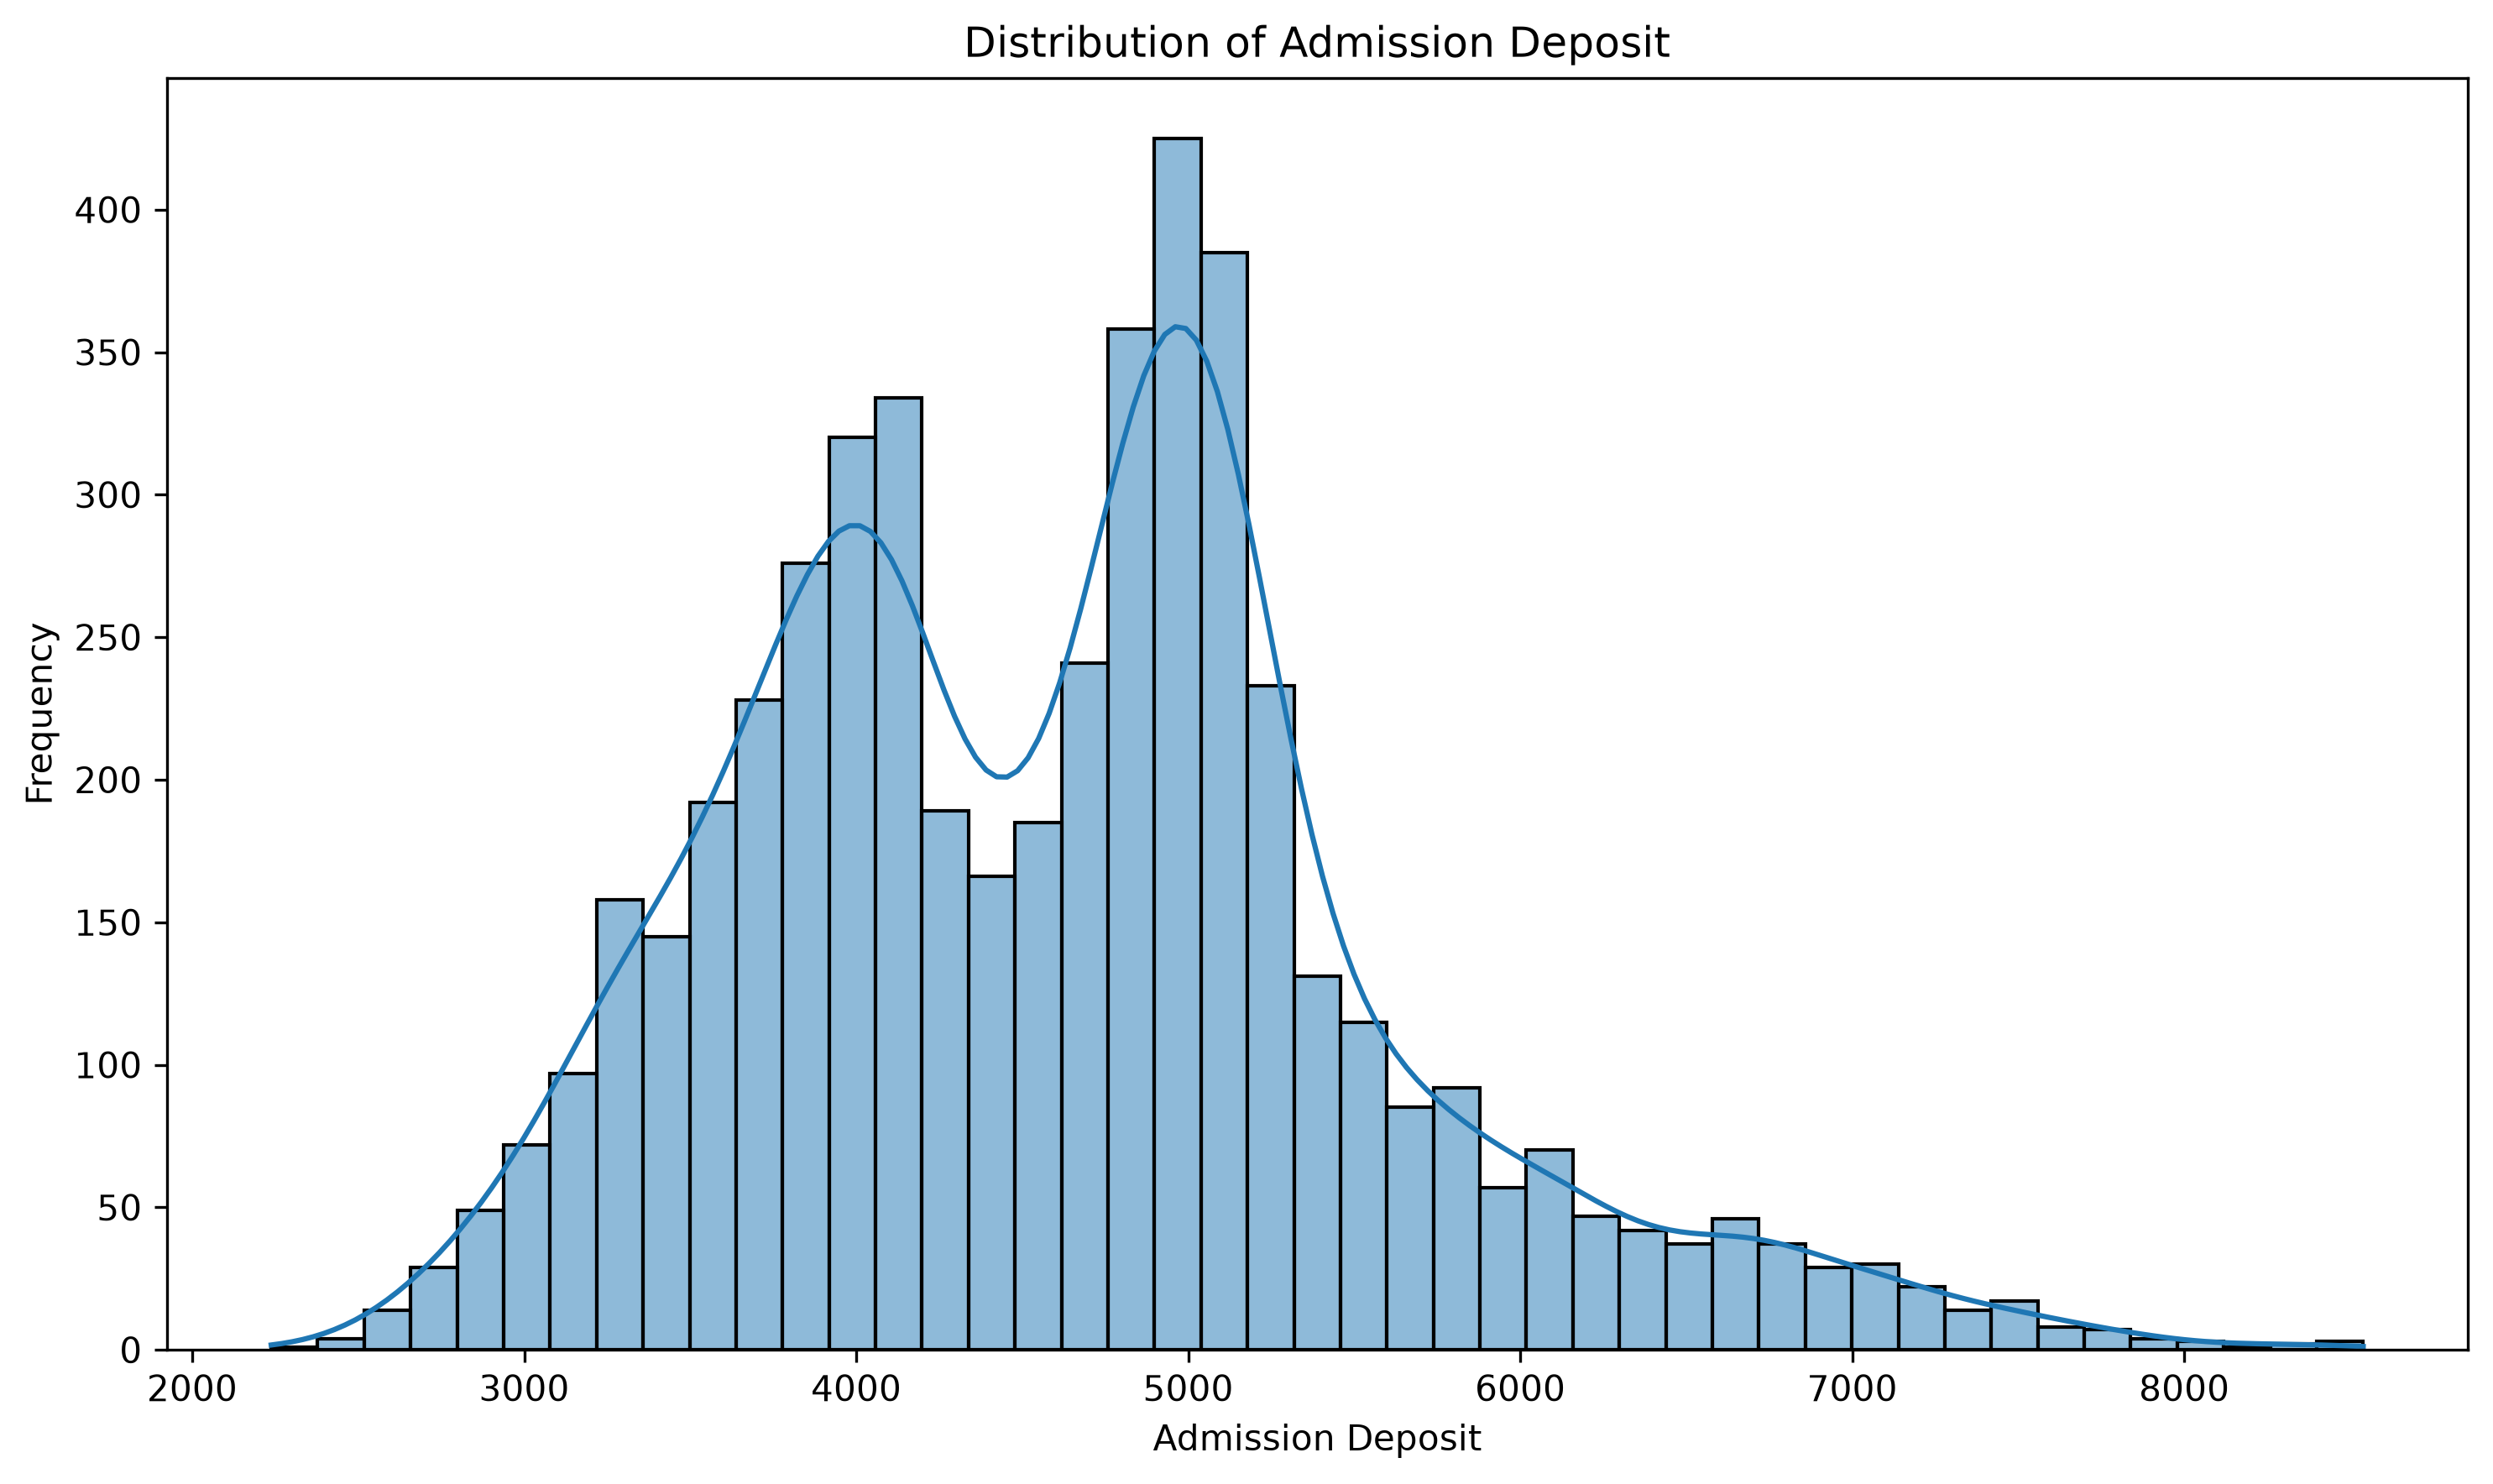

In [45]:
# ============================================================
# DISPLAY ALL GENERATED FIGURES FOR REVIEW
# ============================================================

from PIL import Image
from IPython.display import display
from pathlib import Path

figure_files = sorted(FIGURES_DIR.glob("*.png"))

print(f"Total figures: {len(figure_files)}\n")

for figure_file in figure_files:
    print("=" * 70)
    print(figure_file.name)
    
    img = Image.open(figure_file)
    display(img)

In [46]:
# ============================================================
# CREATE README.md
# ============================================================

readme_lines = [
    "# Assignment 2: Performance Comparison of MLR and KNNR",
    "",
    "## 1. Objective",
    "",
    "This assignment compares Multiple Linear Regression (MLR) and K-Nearest Neighbors Regression (KNNR).",
    "",
    "The models are evaluated using R², MAE, RMSE, execution time, and runtime memory utilization.",
    "",
    "## 2. Dataset",
    "",
    f"Dataset: Hospital Synthetic Dataset",
    f"Number of observations: {df.shape[0]}",
    f"Number of original variables: {df.shape[1]}",
    "Target variable: Admission_Deposit",
    "",
    "The dataset is stored in data/HospitalSynthetic1_cleaned.csv.",
    "",
    "## 3. Methodology",
    "",
    "The dataset was inspected for missing values, duplicate records, data types, and descriptive statistics.",
    "",
    "The case_id identifier was excluded because it is an identification field rather than a meaningful predictor.",
    "",
    "The data was divided into 80% training data and 20% testing data using random_state=42.",
    "",
    "StandardScaler was used to standardize the predictor variables.",
    "",
    "Multiple Linear Regression was trained as the linear regression model.",
    "",
    "KNN Regression was evaluated for K values from 1 to 30.",
    "",
    f"The selected K value was {best_k}, based on the lowest RMSE.",
    "",
    "## 4. Model Performance",
    "",
    "| Model | R² | MAE | RMSE |",
    "|---|---:|---:|---:|",
    f"| Multiple Linear Regression | {mlr_r2:.4f} | {mlr_mae:.2f} | {mlr_rmse:.2f} |",
    f"| KNN Regression | {knn_r2:.4f} | {knn_mae:.2f} | {knn_rmse:.2f} |",
    "",
    "## 5. Execution Time",
    "",
    "| Model | Training Time (s) | Prediction Time (s) |",
    "|---|---:|---:|",
    f"| Multiple Linear Regression | {mlr_training_time:.6f} | {mlr_prediction_time:.6f} |",
    f"| KNN Regression | {knn_training_time:.6f} | {knn_prediction_time:.6f} |",
    "",
    "## 6. KNN Hyperparameter Tuning",
    "",
    "K values from 1 to 30 were tested.",
    "",
    f"Selected K: {best_k}",
    "",
    "The tuning results are stored in results/knn_tuning_results.csv.",
    "",
    "The K vs RMSE plot is stored in figures/knn_k_vs_rmse.png.",
    "",
    "## 7. Evaluation Metrics",
    "",
    "R² measures the proportion of variation in the target variable explained by the model.",
    "",
    "MAE represents the average absolute prediction error.",
    "",
    "RMSE represents the square root of the average squared prediction error and gives greater weight to larger errors.",
    "",
    "## 8. Visualizations",
    "",
    "The assignment includes target distribution, correlation heatmap, actual-versus-predicted plots, residual plots, KNN tuning plots, metric comparison plots, and execution-time comparison.",
    "",
    "All figures are stored in the figures folder.",
    "",
    "## 9. Resource Utilization",
    "",
    "Runtime memory usage was recorded using psutil.",
    "",
    "The result is stored in results/resource_utilization.csv.",
    "",
    "This represents runtime process memory and should not be interpreted as theoretical algorithmic memory complexity.",
    "",
    "## 10. Results",
    "",
    f"MLR R² = {mlr_r2:.4f}",
    f"KNNR R² = {knn_r2:.4f}",
    "",
    "The relatively low R² values indicate that the selected predictor variables explain only a limited proportion of the variation in Admission_Deposit.",
    "",
    "The MAE and RMSE values provide additional information about prediction error magnitude.",
    "",
    "## 11. Project Structure",
    "",
    "Assignment2/",
    "├── data/",
    "│   └── HospitalSynthetic1_cleaned.csv",
    "├── figures/",
    "├── notebook/",
    "│   └── Assignment2_MLR_KNNR.ipynb",
    "├── results/",
    "├── .gitignore",
    "└── README.md",
    "",
    "## 12. Technologies Used",
    "",
    "Python, Jupyter Notebook, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, and psutil.",
    "",
    "## 13. Reproducibility",
    "",
    "A fixed random state of 42 was used for the train-test split.",
    "",
    "The complete analysis is contained in the Jupyter Notebook."
]

readme_content = "\n".join(readme_lines)

README_FILE = PROJECT_DIR / "README.md"

README_FILE.write_text(
    readme_content,
    encoding="utf-8"
)

print("README.md created successfully!")
print("Location:", README_FILE)

README.md created successfully!
Location: C:\Users\drish\OneDrive\assignment 2\README.md


In [47]:
# ============================================================
# CREATE .gitignore
# ============================================================

gitignore_content = """# Jupyter
.ipynb_checkpoints/

# Python
__pycache__/
*.py[cod]

# Virtual environments
.venv/
venv/
env/

# OS files
.DS_Store
Thumbs.db

# Temporary files
*.tmp
*.temp
"""

GITIGNORE_FILE = PROJECT_DIR / ".gitignore"

GITIGNORE_FILE.write_text(
    gitignore_content,
    encoding="utf-8"
)

print(".gitignore created successfully!")
print("Location:", GITIGNORE_FILE)

.gitignore created successfully!
Location: C:\Users\drish\OneDrive\assignment 2\.gitignore


In [48]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
GITIGNORE_FILE = PROJECT_DIR / ".gitignore"

if not GITIGNORE_FILE.exists():
    gitignore_content = """# Jupyter
.ipynb_checkpoints/

# Python
__pycache__/
*.py[cod]

# Virtual environments
.venv/
venv/
env/

# OS files
.DS_Store
Thumbs.db

# Temporary files
*.tmp
*.temp
"""

    GITIGNORE_FILE.write_text(
        gitignore_content,
        encoding="utf-8"
    )

    print(".gitignore created.")
else:
    print(".gitignore already exists.")

print("Location:", GITIGNORE_FILE)

.gitignore already exists.
Location: C:\Users\drish\OneDrive\assignment 2\.gitignore
